# Electricity Demand Forecasting
### Complete Google Colab execution

Run **Runtime → Run all**. Each phase is a separate Colab cell, so printed results, tables, and graphs appear directly below the relevant code.

In [1]:
# ELECTRICITY DEMAND FORECASTING — GOOGLE COLAB SETUP
# Run this cell first. It installs dependencies, finds the uploaded project ZIP,
# extracts it when necessary, and puts the project root on Python's import path.

import os
import sys
import warnings
import subprocess
import zipfile
from pathlib import Path

warnings.filterwarnings("ignore")

def install_packages():
    packages = [
        "numpy", "pandas", "matplotlib", "scipy",
        "scikit-learn", "statsmodels", "xgboost", "openpyxl"
    ]
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q"] + packages
    )

def find_project_root(base):
    base = Path(base)
    if (base / "src").is_dir():
        return base
    for p in base.rglob("src"):
        if p.is_dir():
            return p.parent
    return None

install_packages()

ROOT = find_project_root("/content")

if ROOT is None:
    from google.colab import files

    print("Upload the complete Electricity-Demand-Forecasting project ZIP.")
    uploaded = files.upload()
    zip_files = [x for x in uploaded if x.lower().endswith(".zip")]

    if not zip_files:
        raise FileNotFoundError("Please upload the project ZIP containing src/.")

    zip_path = Path("/content") / zip_files[0]
    extract_dir = Path("/content/electricity_demand_project")
    extract_dir.mkdir(exist_ok=True)

    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(extract_dir)

    ROOT = find_project_root(extract_dir)

if ROOT is None:
    raise FileNotFoundError(
        "The project root containing src/ could not be found."
    )

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from IPython.display import Image, display

print("=" * 88)
print("ELECTRICITY DEMAND FORECASTING — GOOGLE COLAB")
print(f"Project root: {ROOT}")
print("=" * 88)

print("src/       :", (ROOT / "src").exists())
print("data/      :", (ROOT / "data").exists())
print("results/   :", (ROOT / "results").exists())
print("scripts/   :", (ROOT / "scripts").exists())

def show(fig_name, width=900):
    fig = ROOT / "results" / "figures" / f"{fig_name}.png"
    if fig.exists():
        display(Image(filename=str(fig), width=width))
    else:
        print(f"[Figure not found] {fig}")


Upload the complete Electricity-Demand-Forecasting project ZIP.


Saving Electricity-Demand-Forecasting-for-Power-Distribution-Utilities-main.zip to Electricity-Demand-Forecasting-for-Power-Distribution-Utilities-main.zip
ELECTRICITY DEMAND FORECASTING — GOOGLE COLAB
Project root: /content/electricity_demand_project/Electricity-Demand-Forecasting-for-Power-Distribution-Utilities-main
src/       : True
data/      : True
results/   : True
scripts/   : True


## Phase 2 — Exploratory Data Analysis



PHASE 2 — EXPLORATORY DATA ANALYSIS
Observed hours : 23,977   (01 Apr 2023 → 12 Jan 2026)
Missing hours: 455  in 241 gaps
mean     1.9
50%      1.0
max     49.0
Gaps ≤ 3 h: 223,  longer: 18


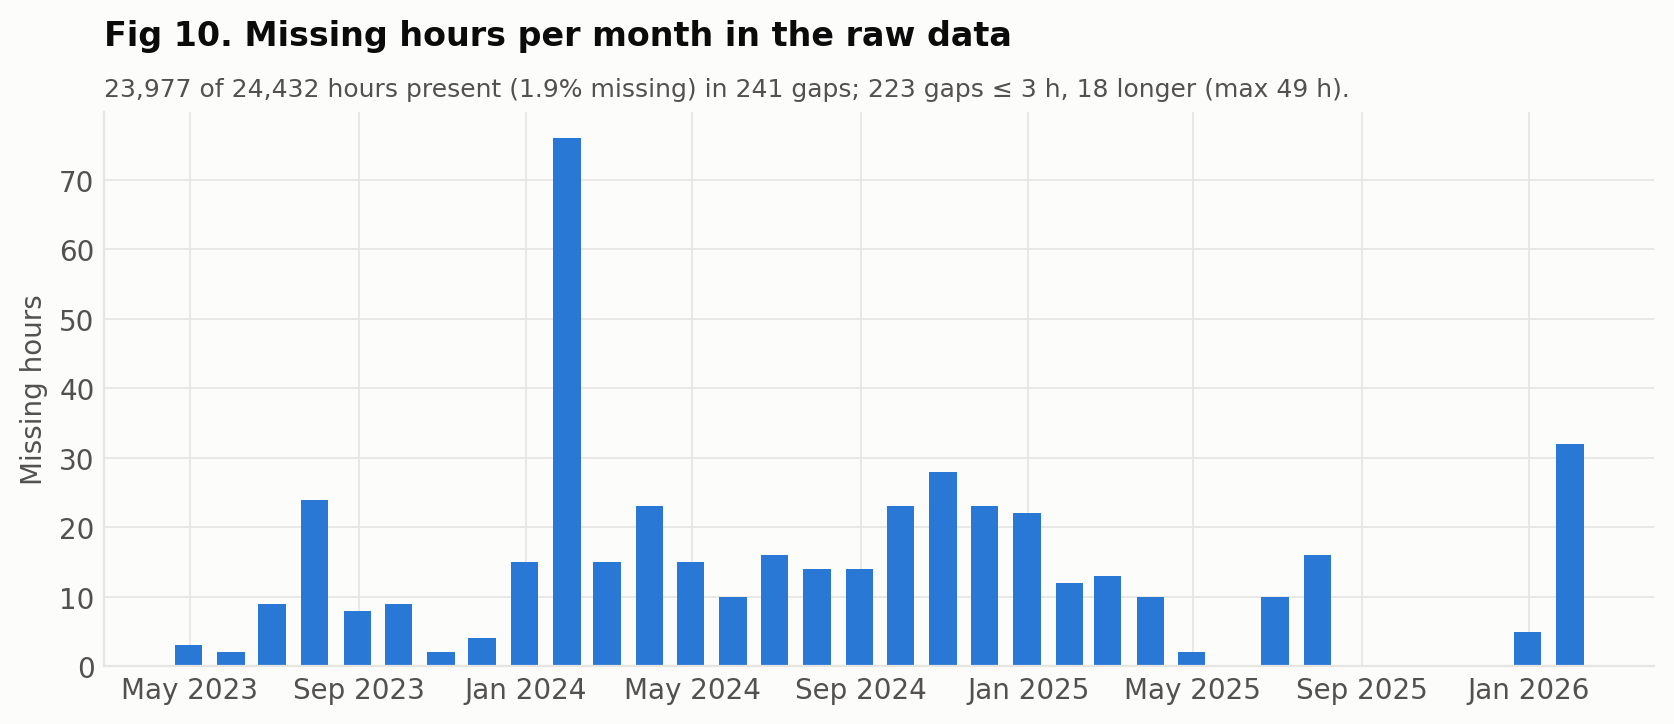

μ = 4,313 MW, σ = 1,340 MW  →  11 hours beyond ±3σ
months: {1: 211, 2: 210, 3: 125, 4: 8, 11: 209, 12: 320}
hours : {0: 48, 1: 228, 2: 276, 3: 243, 4: 281, 5: 7}


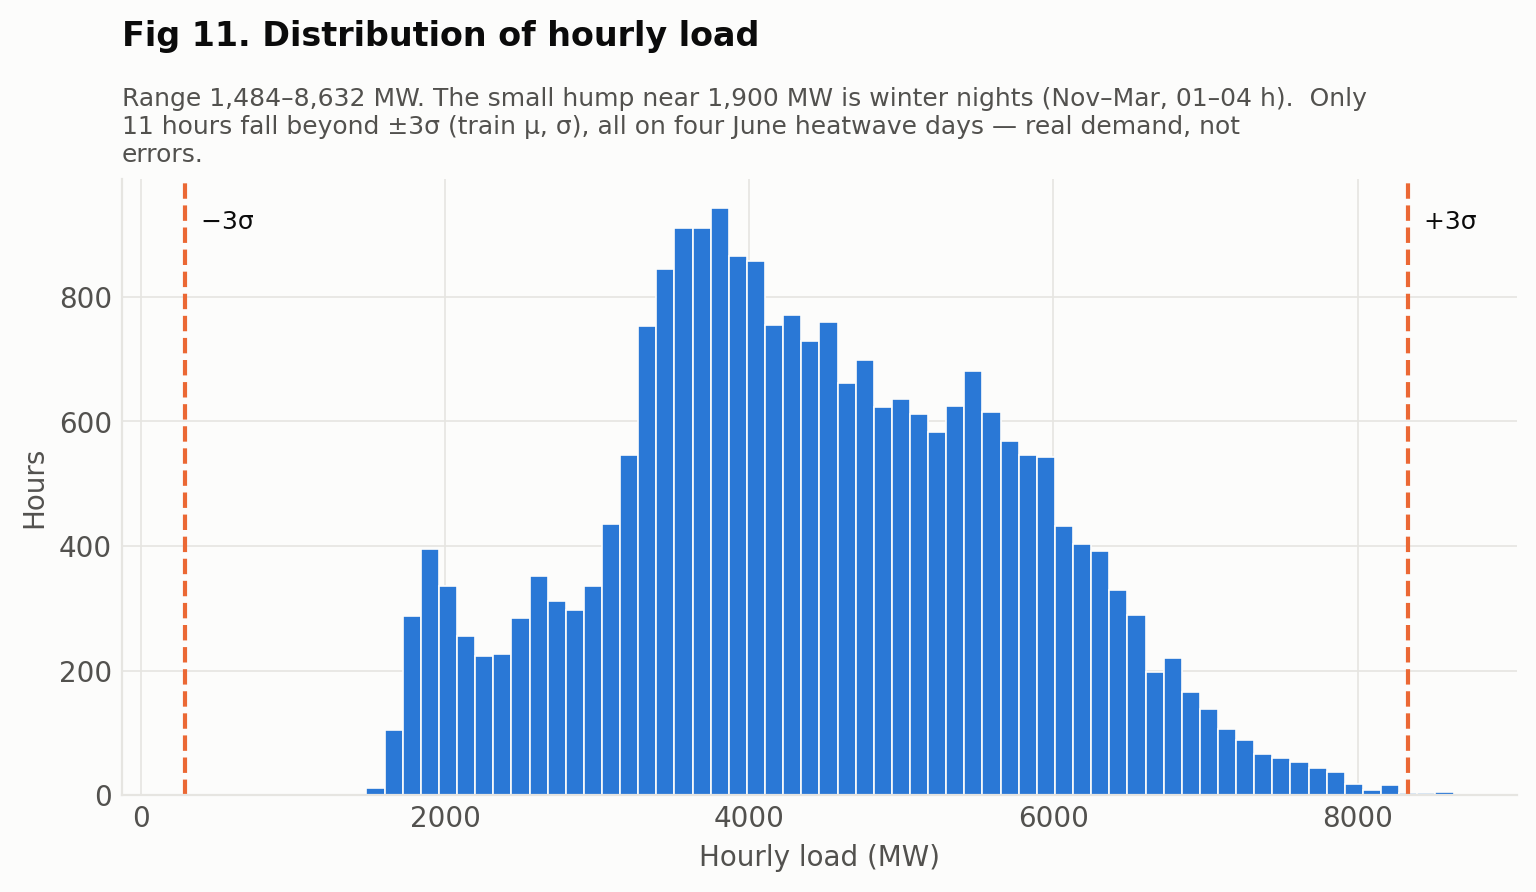

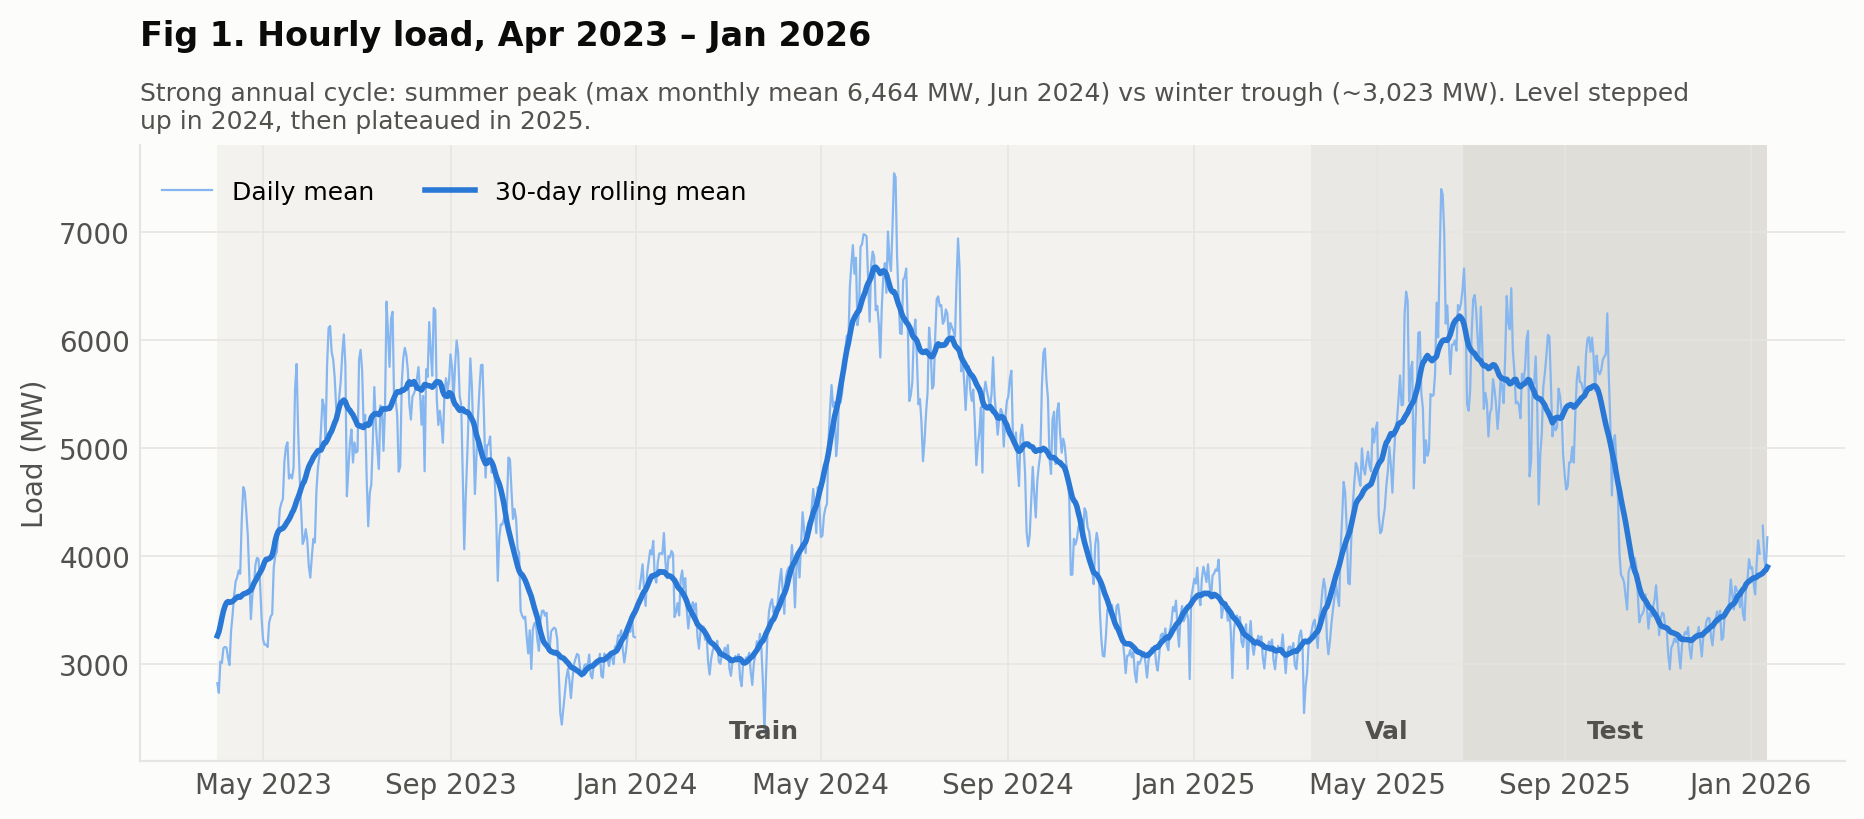

2024 vs 2023 (same months): +11.2%
2025 vs 2024 (same months): -0.7%


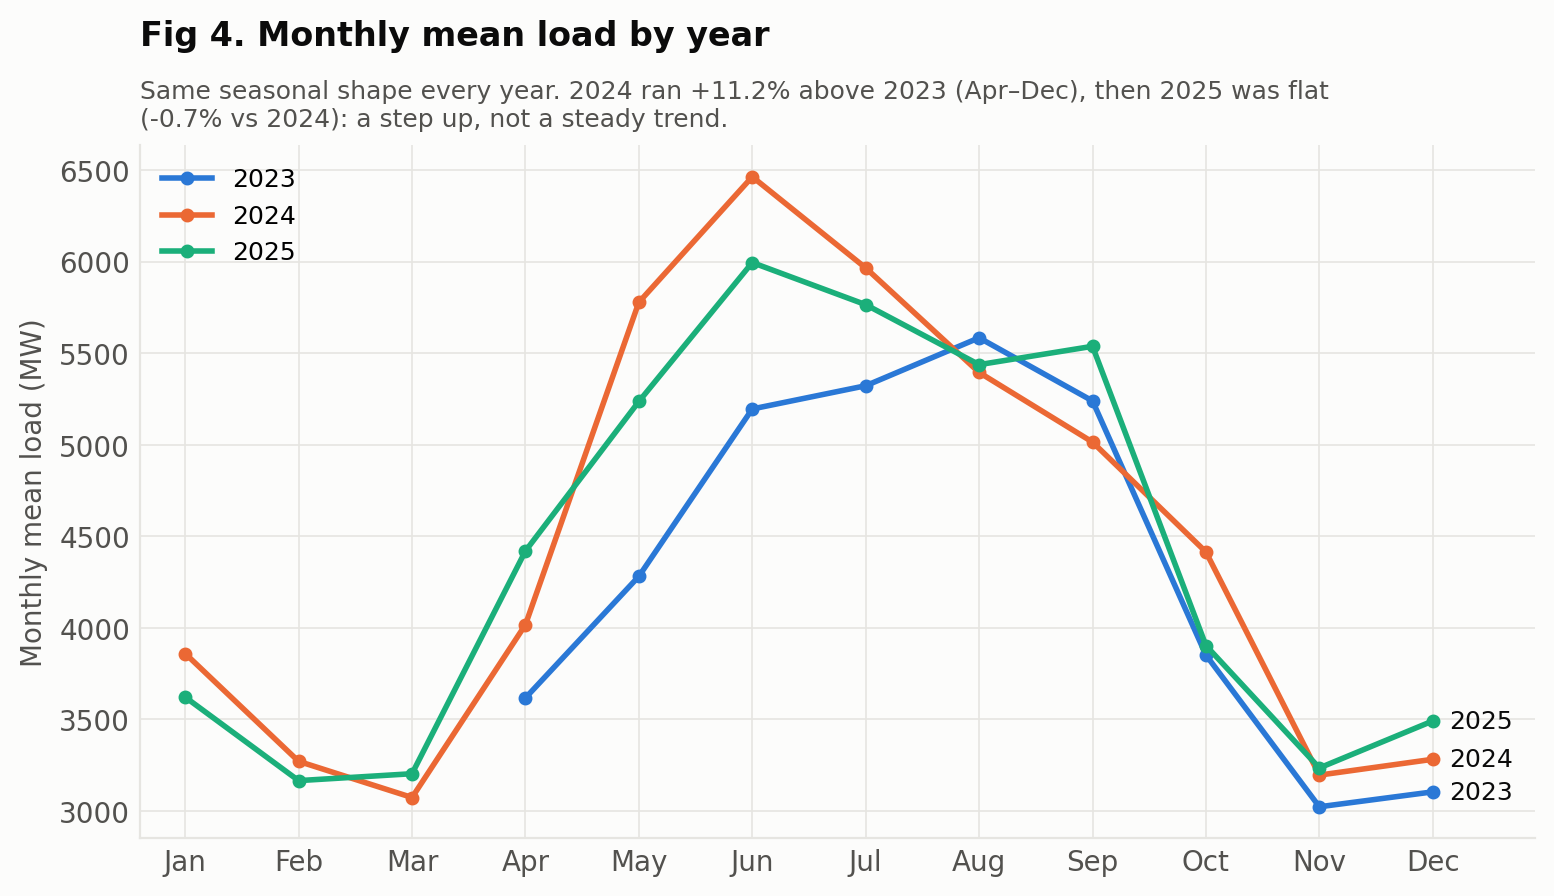

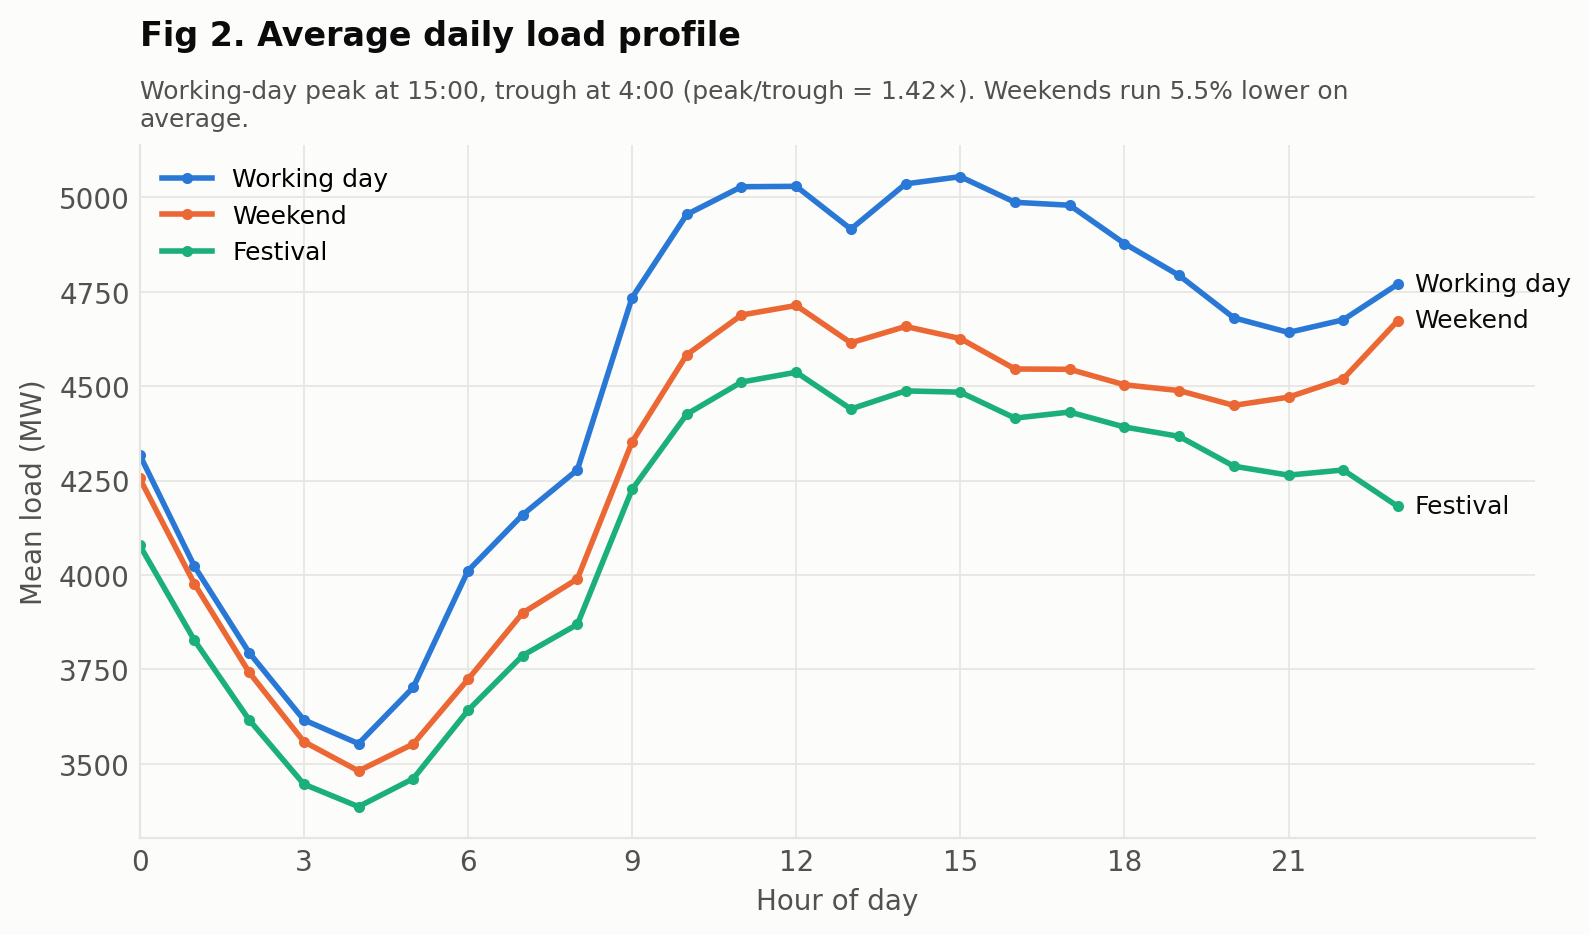

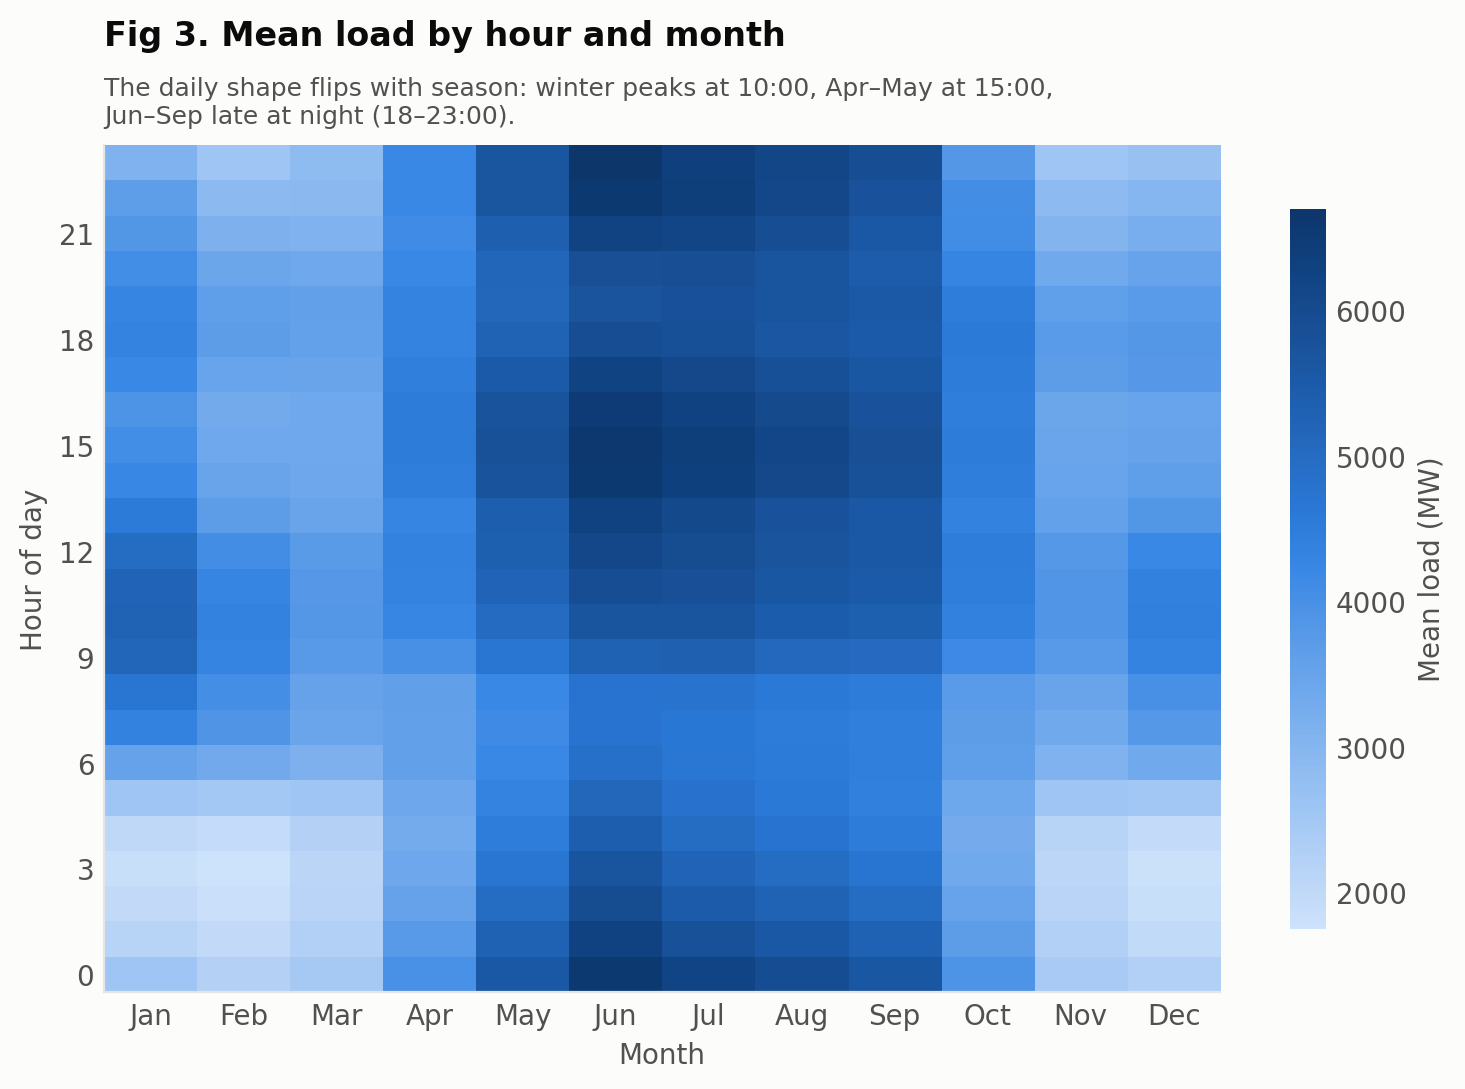

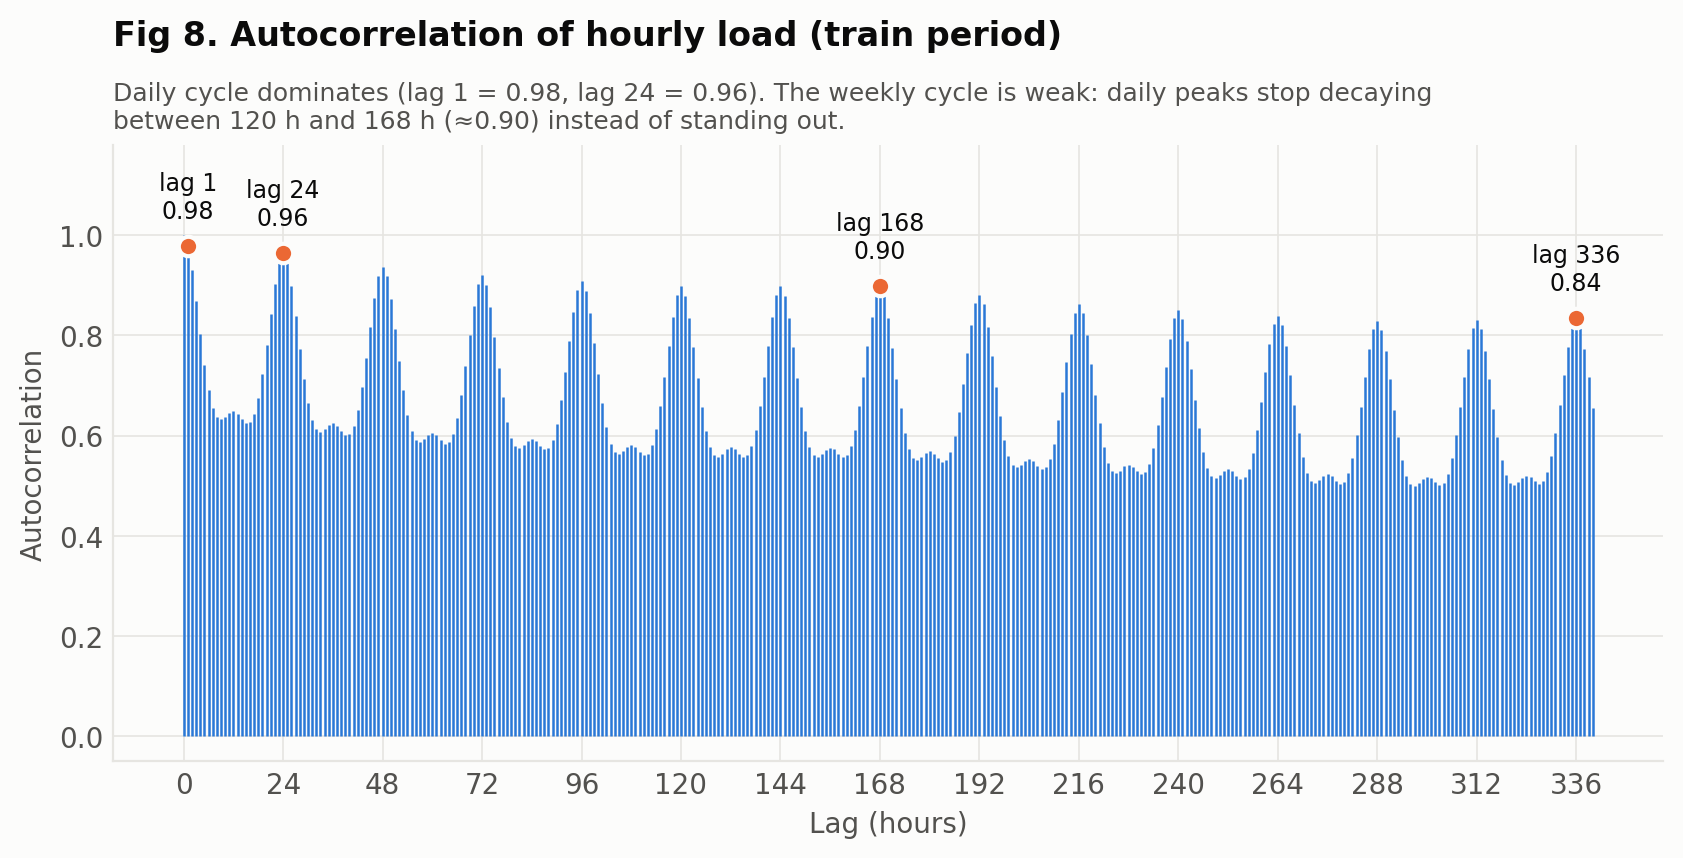

def calendar_residual(df, keys=("hour", "dow", "month")):
    """Load minus the mean load of the same calendar cell (e.g. same hour, weekday, month).
    What remains is the part of demand the calendar can NOT explain."""
    cell_mean = df.groupby(list(keys))["load_mw"].transform("mean")
    return df["load_mw"] - cell_mean



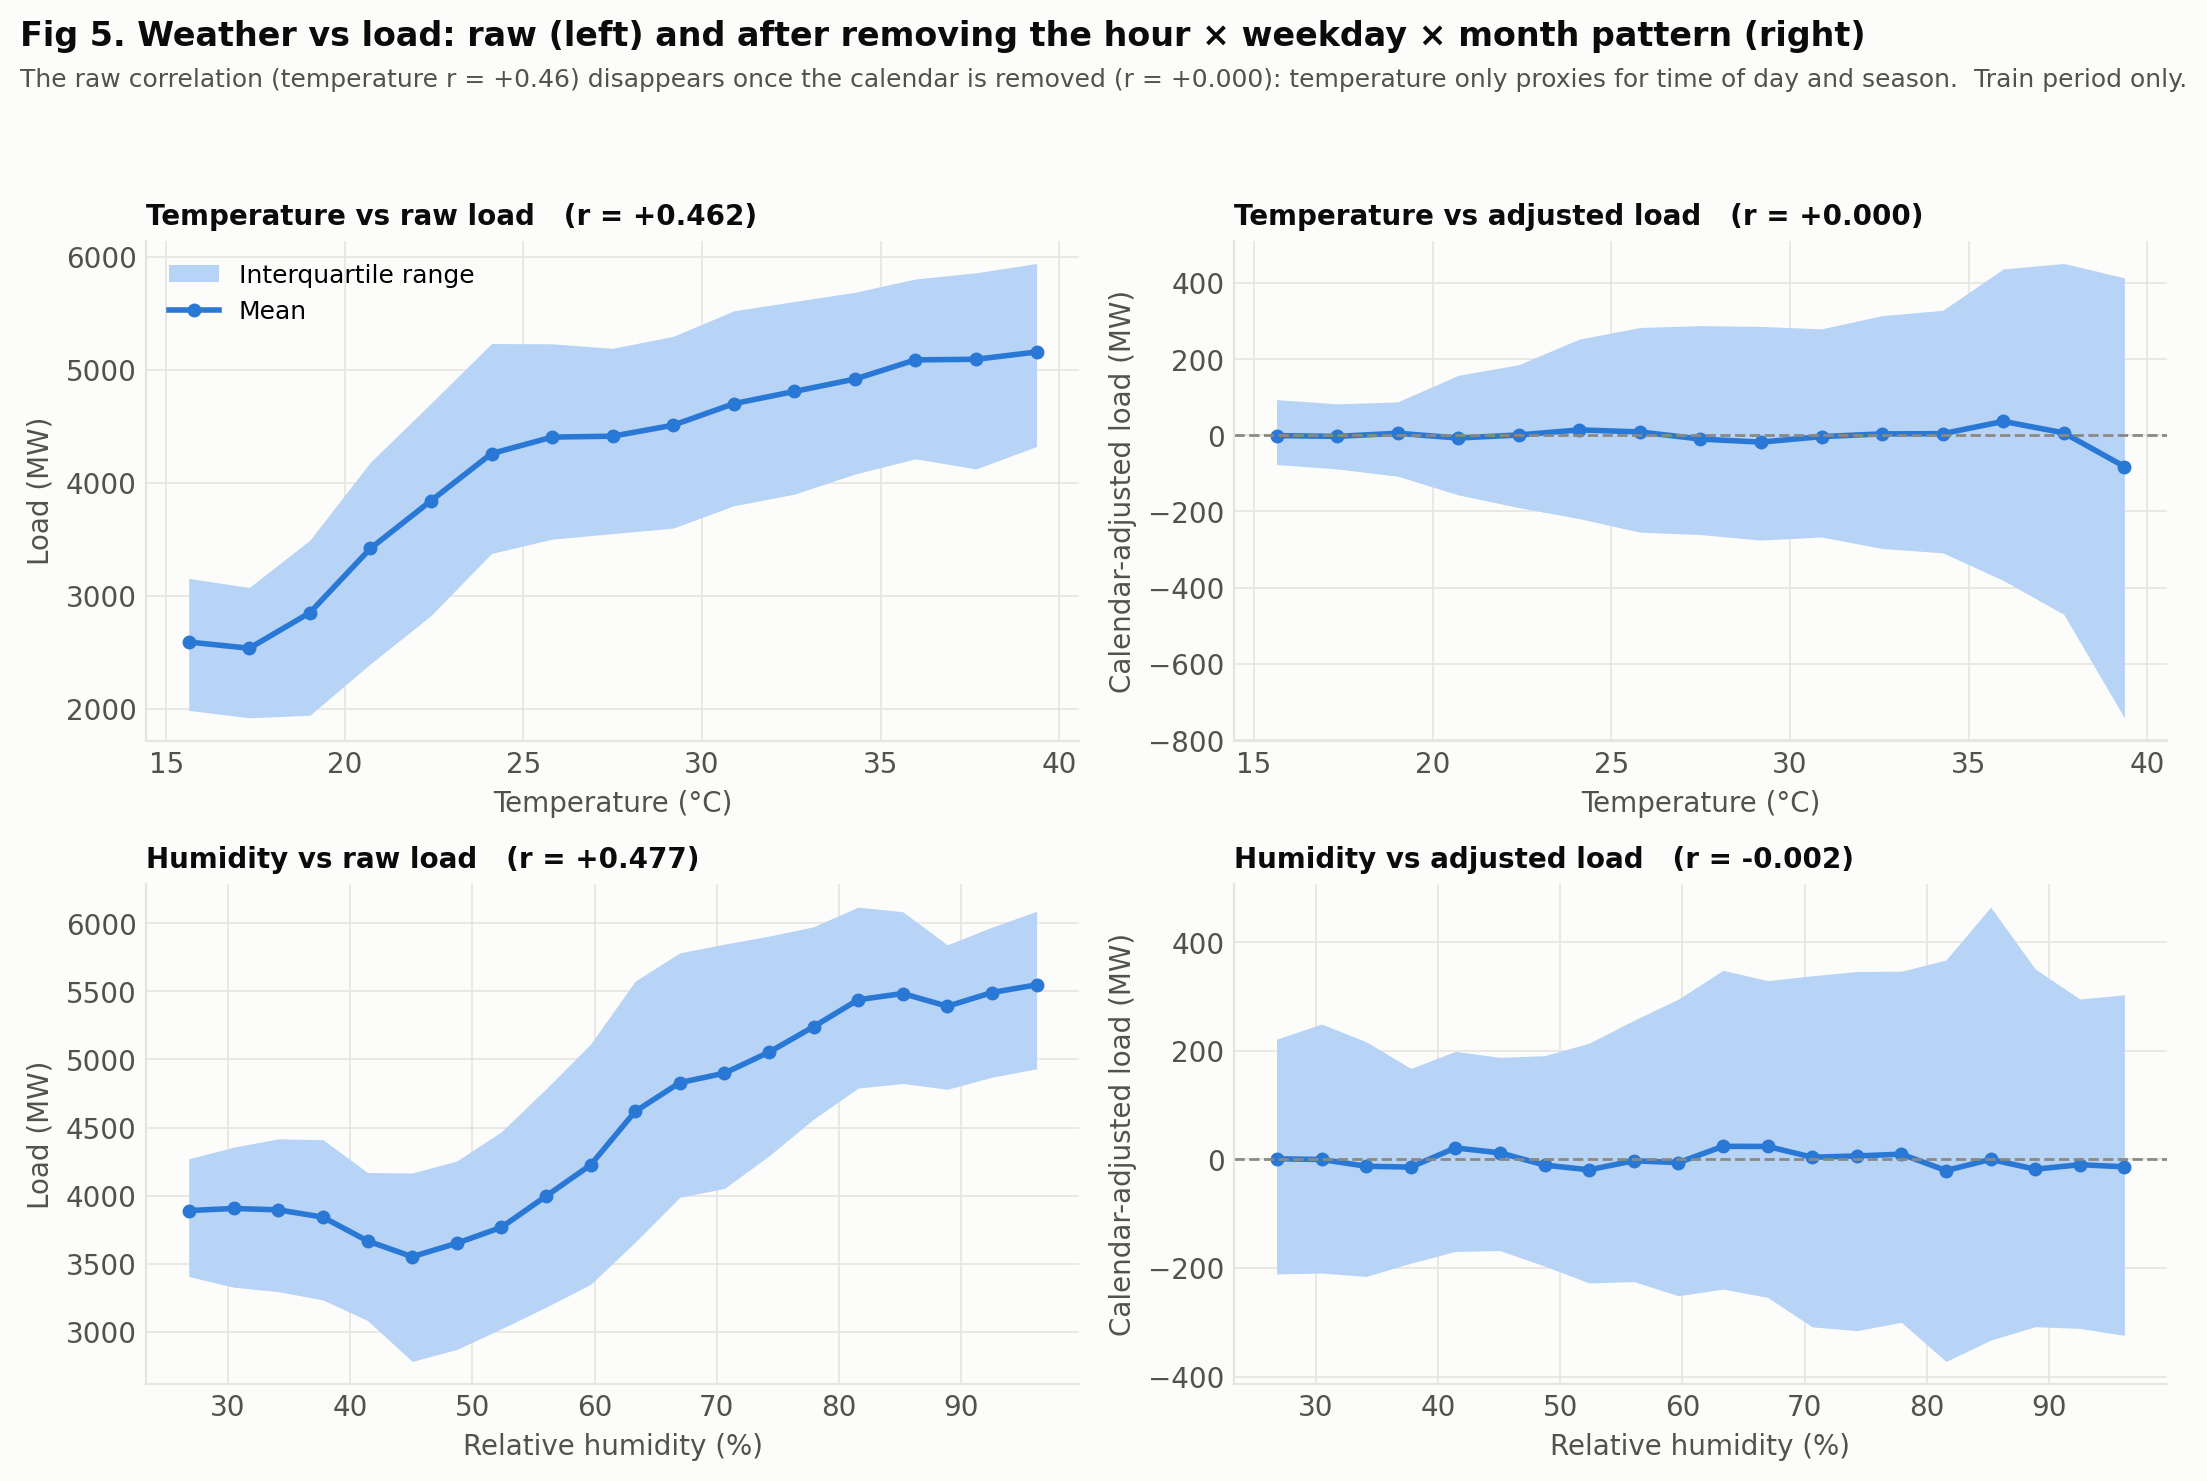

P(same as previous hour) = 0.370   vs   0.336 if independent


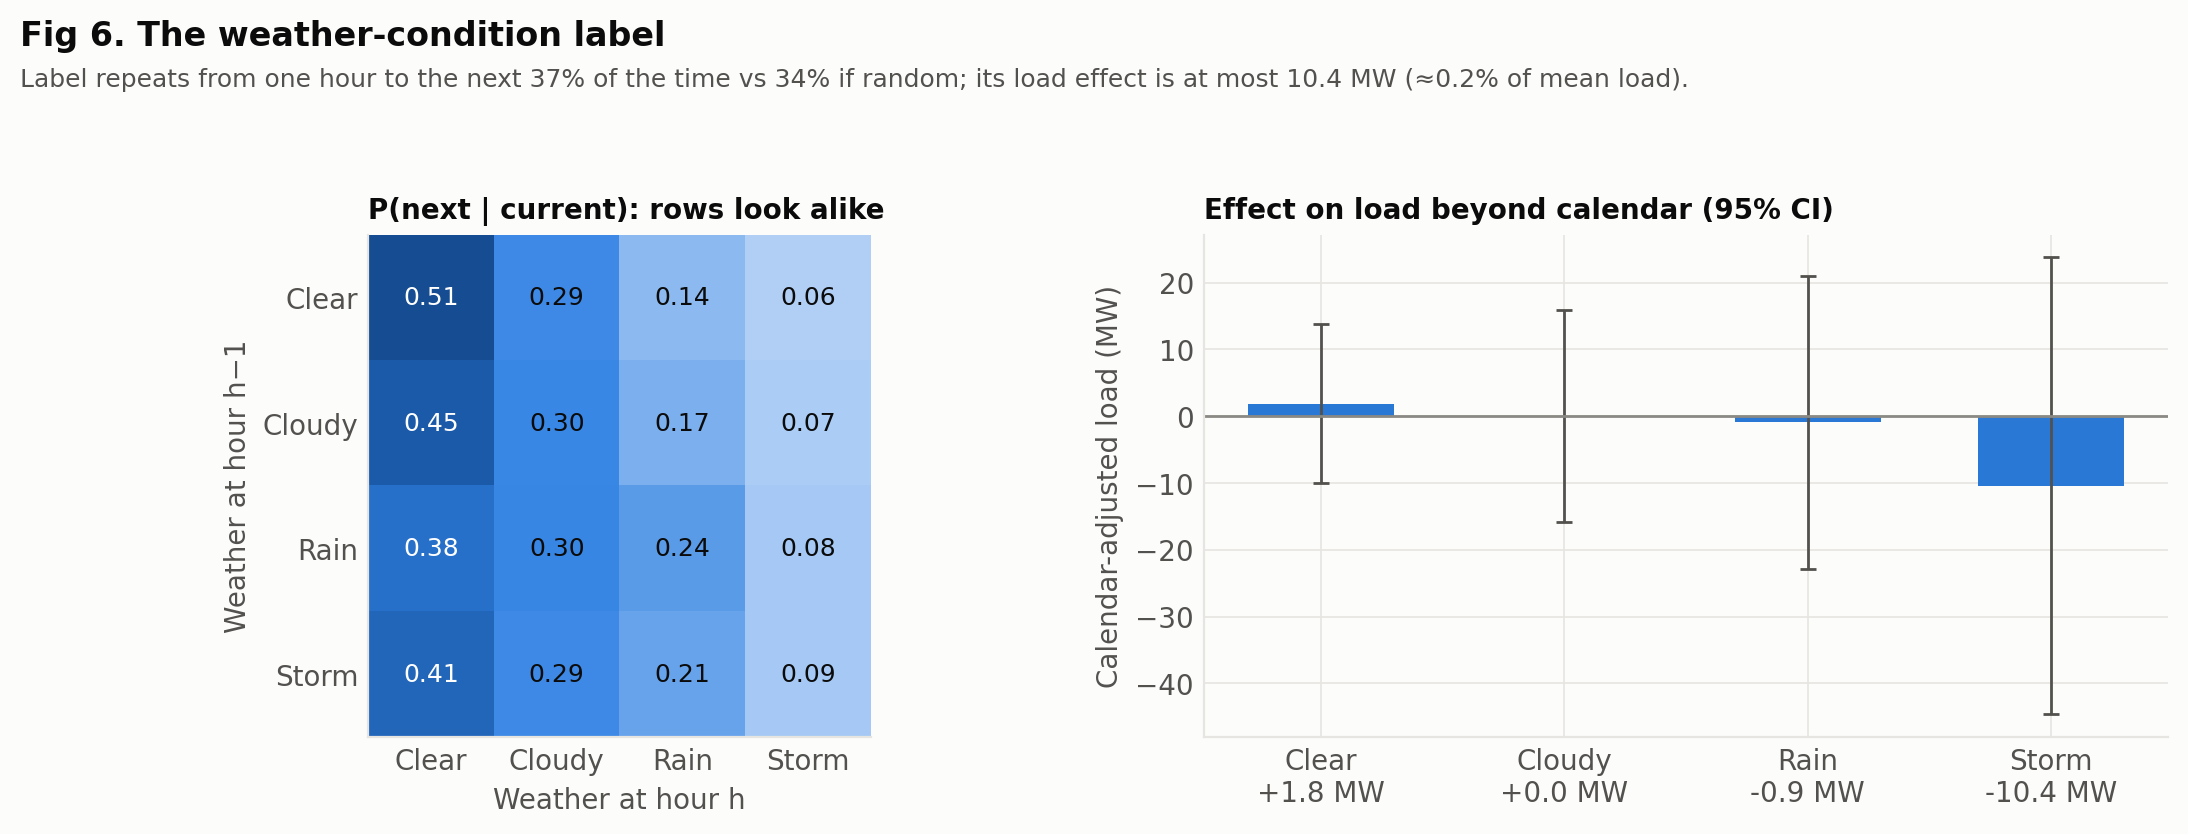

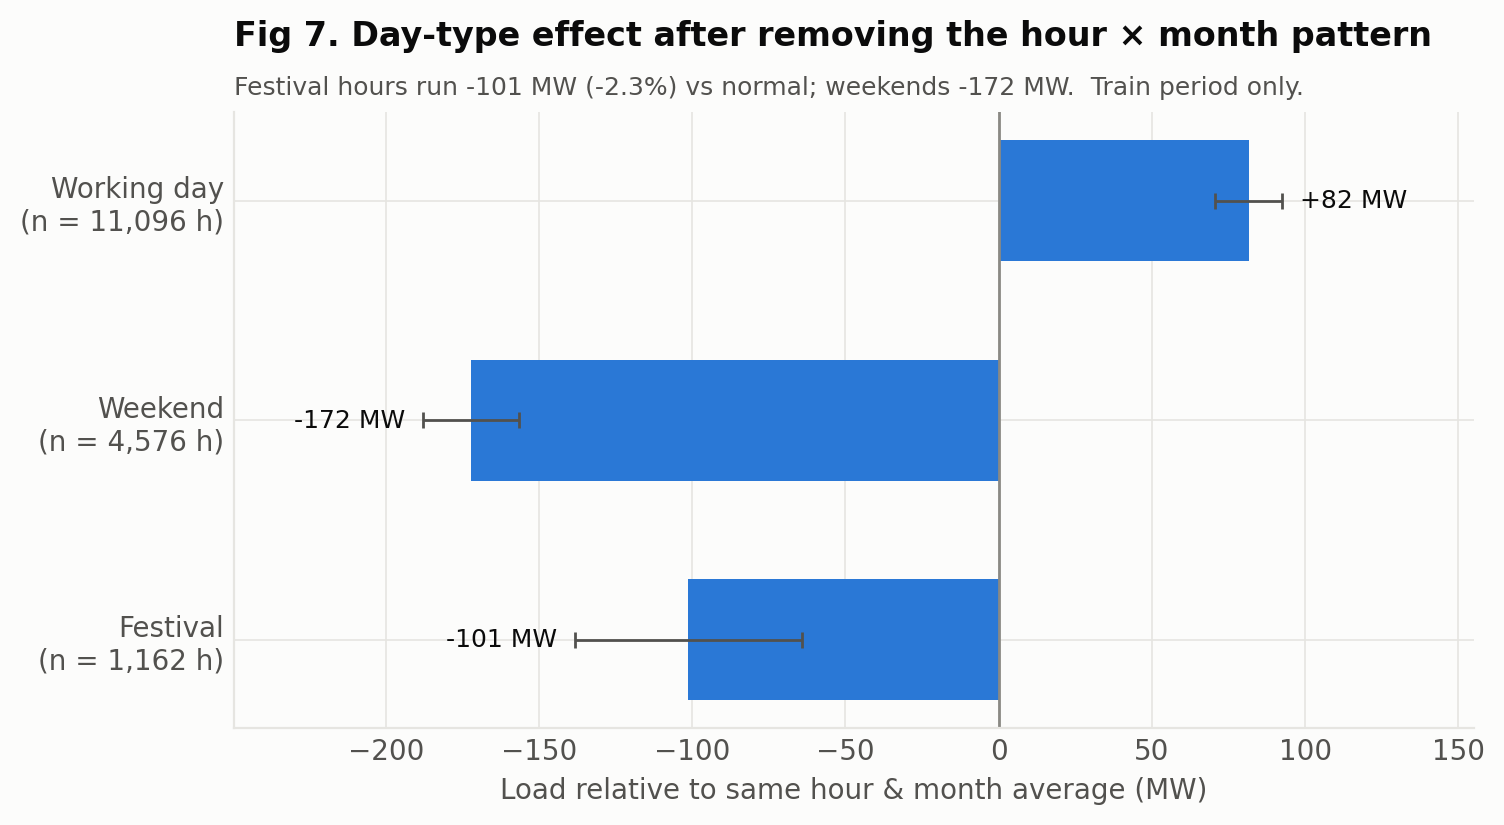

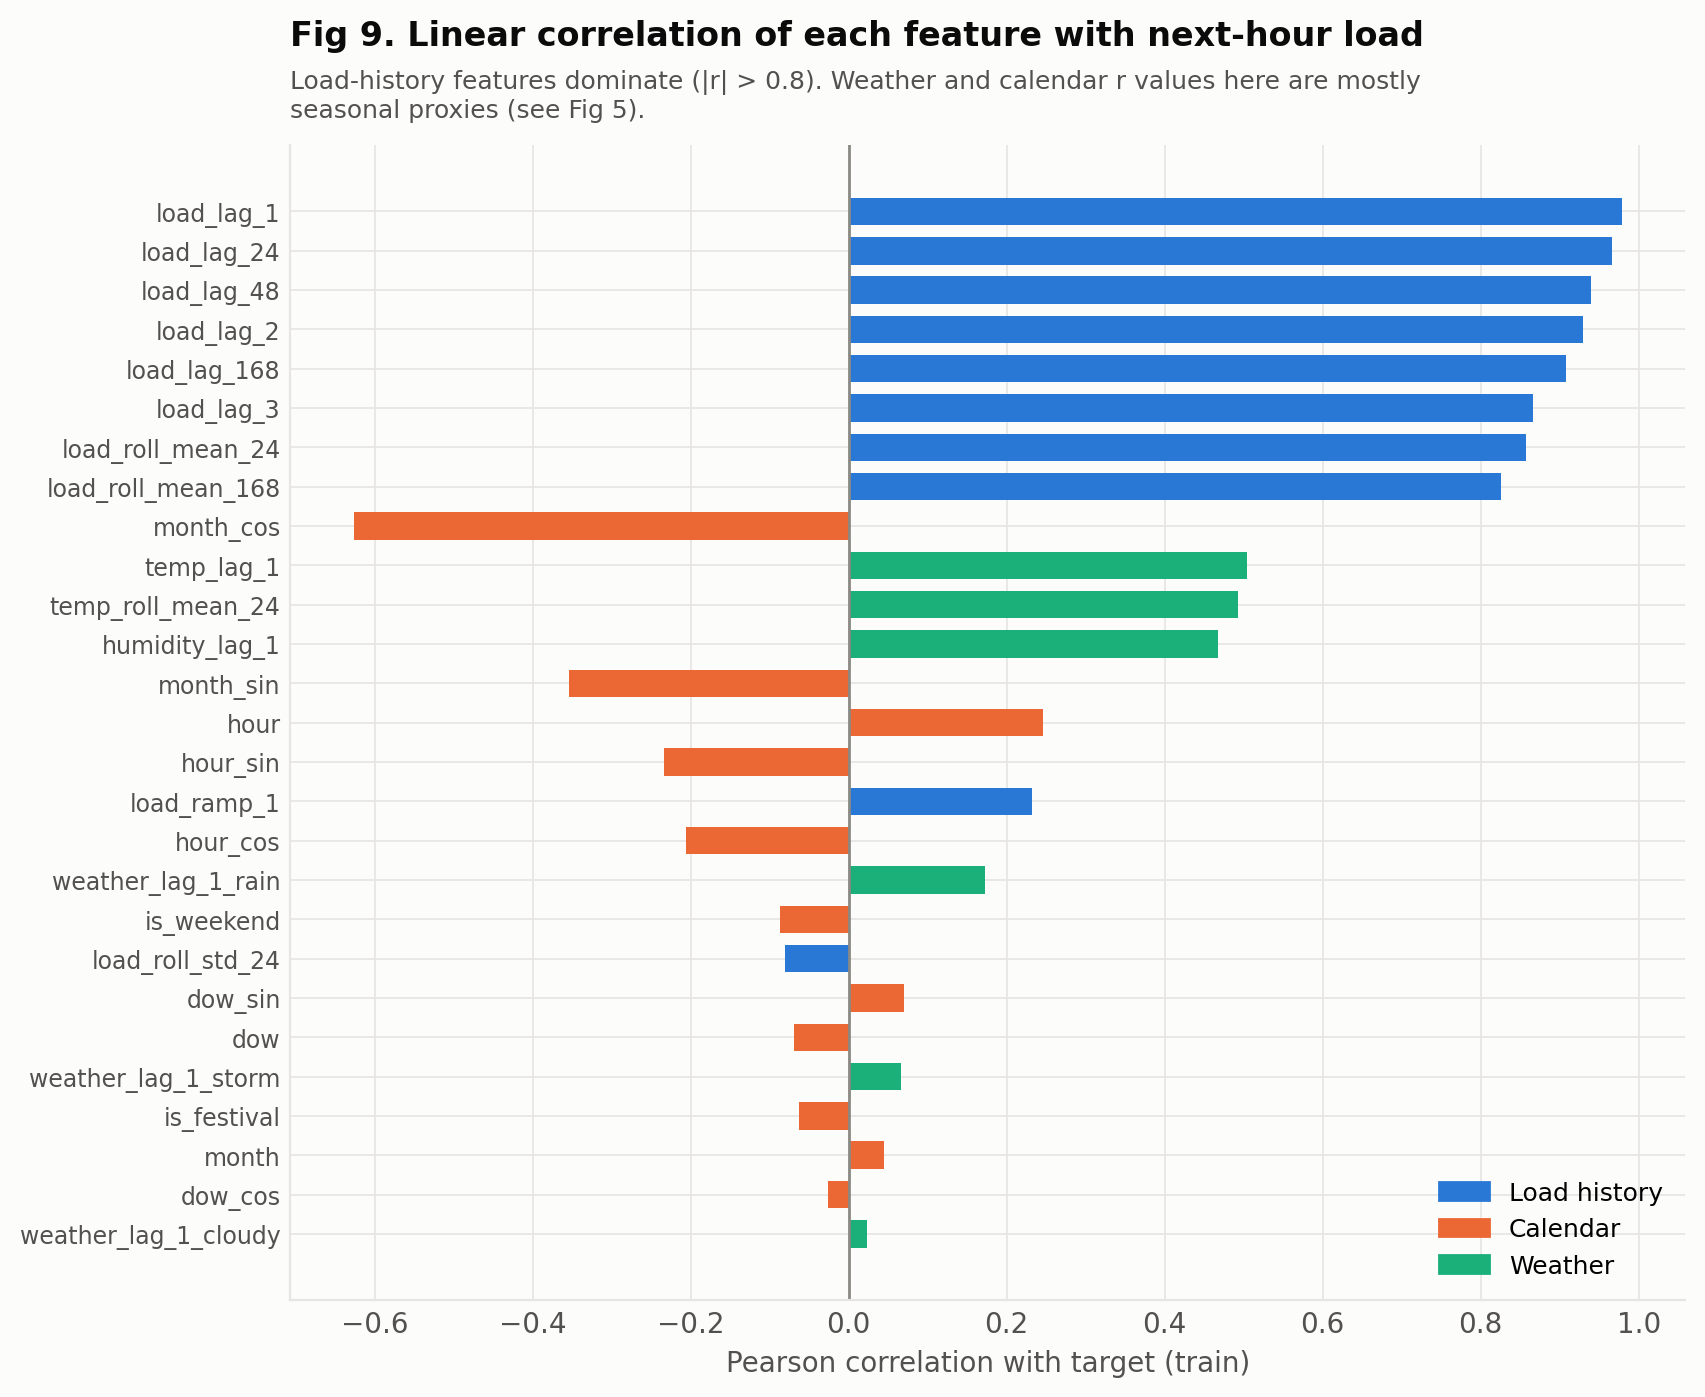

Condition number, all load features: 1.14e+16
Condition number, linear-model load features: 45.2


figure,question,modelling_decision
F01,How does load evolve and where do the splits fall?,"Correction to the Phase 1 note: the Train/Val gap is seasonal, not a growth trend. Month/seasonal features are needed; trees should cope because Train contains two summers."
F02,What does a typical day look like?,"Hour-of-day must be encoded richly: one-hot + sin/cos for linear models, raw hour for trees. Keep is_weekend."
F03,Does the daily shape change with season?,"Hour×month interaction: an additive linear model can't capture it, but trees can. Expect a clear gap between linear and non-linear models."
F04,Is there a growth trend the models must extrapolate?,"No de-trending step: Train already contains the higher 2024 level, and the lags and rolling means carry the recent level into each forecast. Test (H2 2025) sits on the plateau."
F05,Does weather drive load beyond the calendar?,"Keep the weather features (the ablation will test them), but expect ≈0 gain. Consistent with v1, where adding weather did not improve MAE. Report it as a data limitation."
F06,Is the weather label informative?,Only seasonal information (more rain in Jun–Sep). Lagged one-hot kept for completeness; Lasso should zero it out.
F07,Do festivals and weekends change load?,"Keep is_festival and is_weekend: small but real effects. Festivals are rare (≈7% of hours), so expect a small overall gain that is larger on festival hours."
F08,Which past hours carry information?,"Justifies lags 1–3, 24 and 48. Lag 168 is kept but expected to add little; Lasso will tell. Lag 1 alone should give a strong naive baseline (Phase 3), and naive-24 should beat naive-168."
F09,Which features relate linearly to the target?,"Strong collinearity among load lags (lag1, lag2, lag3, roll_mean_24): plain OLS coefficients will be unstable. This motivates Ridge (L2) and Lasso (L1) in Phase 4."
F10,How complete is the data?,"Phase 1 policy holds: forward-fill ≤3 h, seasonal fill for long gaps (history only), imputed hours never scored."


In [2]:
print("\n" + "=" * 88)
print("PHASE 2 — EXPLORATORY DATA ANALYSIS")
print("=" * 88)

import numpy as np
import pandas as pd
from IPython.display import Image, display
from src import config, eda, features
pd.set_option('display.precision', 3)

def show(fig_name, width=900):
    display(Image(filename=str(config.FIG_DIR / f'{fig_name}.png'), width=width))
ctx = eda.load_context()
obs, train_obs, sp = (ctx.obs, ctx.train_obs, ctx.sp)
print(f'Observed hours : {len(obs):,}   ({obs.index.min():%d %b %Y} → {obs.index.max():%d %b %Y})')
sp.summary()
from src import data
gaps = data.gap_report(ctx.hourly)
print(f"Missing hours: {ctx.hourly['is_missing_raw'].sum()}  in {len(gaps)} gaps")
print(gaps['hours'].describe()[['mean', '50%', 'max']].round(1).to_string())
print(f'Gaps ≤ 3 h: {(gaps.hours <= 3).sum()},  longer: {(gaps.hours > 3).sum()}')
gaps.sort_values('hours', ascending=False).head(5)
f10 = eda.f10_missing_hours(ctx)
show('F10_missing_hours')
mu, sd = (train_obs['load_mw'].mean(), train_obs['load_mw'].std())
out = obs[(obs['load_mw'] - mu).abs() > 3 * sd]
print(f'μ = {mu:,.0f} MW, σ = {sd:,.0f} MW  →  {len(out)} hours beyond ±3σ')
out[['load_mw']].assign(date=out.index.date, hour=out.index.hour)
low = obs[(obs.load_mw > 1700) & (obs.load_mw < 2100)]
print('months:', low.index.month.value_counts().sort_index().to_dict())
print('hours :', low.index.hour.value_counts().sort_index().to_dict())
f11 = eda.f11_load_distribution(ctx)
show('F11_load_distribution')
f01 = eda.f01_timeline(ctx)
show('F01_timeline_with_split', 1000)
sp.summary()[['split', 'start', 'end', 'mean_mw']]
mm = obs.groupby([obs.index.year, obs.index.month])['load_mw'].mean().unstack(0)
for a, b in [(2023, 2024), (2024, 2025)]:
    both = mm[[a, b]].dropna()
    print(f'{b} vs {a} (same months): {(both[b] / both[a] - 1).mean() * 100:+.1f}%')
f04 = eda.f04_year_on_year(ctx)
show('F04_year_on_year')
f02 = eda.f02_daily_profile(ctx)
show('F02_daily_profile')
hm = obs.pivot_table(index='hour', columns='month', values='load_mw', aggfunc='mean')
peak_hour = hm.idxmax()
pd.DataFrame({'peak hour': peak_hour, 'peak MW': hm.max().round(0)}).T
f03 = eda.f03_heatmap_hour_month(ctx)
show('F03_heatmap_hour_month', 800)
from statsmodels.tsa.stattools import acf
y_train = ctx.hourly.loc[:ctx.TRAIN_END, 'load_mw']
rho = acf(y_train, nlags=340, fft=True)
pd.Series({f'lag {k}': rho[k] for k in [1, 2, 3, 24, 48, 120, 144, 168, 192, 336]}).round(3).to_frame('ACF').T
f08 = eda.f08_autocorrelation(ctx)
show('F08_autocorrelation', 1000)
import inspect
print(inspect.getsource(eda.calendar_residual))
rows = []
t = train_obs.copy()
rows.append(('raw load (no adjustment)', t['temp'].corr(t['load_mw']), t['humidity'].corr(t['load_mw'])))
for keys in [('hour', 'dow', 'month'), ('hour', 'month')]:
    r = eda.calendar_residual(t, keys)
    rows.append((' × '.join(keys) + ' adjusted', t['temp'].corr(r), t['humidity'].corr(r)))
d = t.resample('D')[['load_mw', 'temp']].mean().dropna()
dd = d.groupby(d.index.to_period('M')).transform(lambda x: x - x.mean())
rows.append(('daily, within-month', dd['temp'].corr(dd['load_mw']), np.nan))
pd.DataFrame(rows, columns=['comparison', 'r(temperature)', 'r(humidity)']).set_index('comparison').map(lambda v: '—' if pd.isna(v) else f'{v:+.4f}')
f05 = eda.f05_weather_confounding(ctx)
show('F05_weather_confounding', 1000)
w = ctx.raw['weather']
trans = pd.crosstab(w.shift(1), w, normalize='index')
p_same = (w == w.shift(1)).mean()
p_random = (w.value_counts(normalize=True) ** 2).sum()
print(f'P(same as previous hour) = {p_same:.3f}   vs   {p_random:.3f} if independent')
trans.round(2)
f06 = eda.f06_weather_label(ctx)
show('F06_weather_label', 1000)
t = train_obs.copy()
t['day_type'] = np.select([t['holiday_type'] == 'Festival', t['dow'] >= 5], ['Festival', 'Weekend'], 'Working day')
t['resid_hm'] = eda.calendar_residual(t, ('hour', 'month'))
g = t.groupby('day_type')['resid_hm'].agg(['mean', 'sem', 'size'])
g['95% CI ±'] = 1.96 * g['sem']
g[['mean', '95% CI ±', 'size']].round(1)
f07 = eda.f07_day_type_effect(ctx)
show('F07_day_type_effect')
f09 = eda.f09_feature_correlation(ctx)
show('F09_feature_correlation', 800)
import warnings
from statsmodels.stats.outliers_influence import variance_inflation_factor

def collinearity(cols):
    X = sp.train[cols]
    X = (X - X.mean()) / X.std()
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        vif = pd.Series([variance_inflation_factor(X.values, i) for i in range(len(cols))], index=cols)
    return (np.linalg.cond(X.values), vif)
cond_all, vif_all = collinearity(features.LOAD)
print(f'Condition number, all load features: {cond_all:.2e}')
vif_all.sort_values(ascending=False).map(lambda v: f'{v:.3g}').to_frame('VIF').T
cond_lin, vif_lin = collinearity(features.LOAD_LINEAR)
print(f'Condition number, linear-model load features: {cond_lin:,.1f}')
vif_lin.sort_values(ascending=False).round(1).to_frame('VIF').T
findings = pd.DataFrame([f10, f11, f01, f04, f02, f03, f08, f05, f06, f07, f09]).sort_values('figure')
findings.to_csv(config.TABLE_DIR / 'phase2_eda_findings.csv', index=False)
with pd.option_context('display.max_colwidth', None):
    display(findings[['figure', 'question', 'modelling_decision']].style.hide(axis='index').set_properties(**{'text-align': 'left', 'white-space': 'pre-wrap'}))
import inspect
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
from IPython.display import Image, display

## Phase 3 — Baselines



PHASE 3 — BASELINES
Val : 18 Mar 2025 → 26 Jun 2025  (2,381 h)
Test: 26 Jun 2025 → 12 Jan 2026  (4,762 h)
def evaluate(y_true, y_pred) -> dict:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    if np.any(y_true <= 0):
        raise ValueError("MAPE undefined: non-positive actual load")
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAPE": float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100),
        "R2": r2_score(y_true, y_pred),
        "Bias": float(np.mean(y_true - y_pred)),   # >0 = under-forecast on average
    }

{'Naive-1 (persistence)': 'load_lag_1', 'Seasonal naive-24': 'load_lag_24', 'Seasonal naive-168': 'load_lag_168'}
Naive-1 (persistence)    equals y(h-1) from raw series: True
Seasonal naive-24        equals y(h-24) from raw series: True
Seasonal naive-168       equals y(h-168) from raw series: True
class CalendarClimatology:
   

,model,MAE,RMSE,MAPE,R2,Bias,skill_vs_naive1
0,Naive-1 + hourly step,94.15,147.22,1.98,0.98,0.65,0.51
1,Naive-1 (persistence),192.43,253.08,3.95,0.95,1.02,0.00
2,Seasonal naive-24,319.54,466.37,6.40,0.84,37.85,-0.66
3,Calendar climatology,571.16,722.51,11.48,0.62,292.07,-1.97
4,Seasonal naive-168,590.86,781.94,11.43,0.56,217.91,-2.07



TEST — all hours


,model,MAE,RMSE,MAPE,R2,Bias,skill_vs_naive1
0,Naive-1 + hourly step,74.31,104.28,1.77,0.99,2.16,0.64
1,Naive-1 (persistence),204.68,265.20,5.05,0.96,0.42,0.00
2,Seasonal naive-24,247.11,371.22,5.33,0.92,-8.76,-0.21
3,Calendar climatology,396.83,503.67,8.89,0.85,116.06,-0.94
4,Seasonal naive-168,413.91,592.30,8.99,0.79,-72.93,-1.02


TEST — peak hours (load ≥ train 90th percentile)


,model,n,MAE,MAPE,Bias
0,Naive-1 + hourly step,588,66.26,1.01,8.61
1,Naive-1 (persistence),588,193.48,2.95,46.69
2,Seasonal naive-24,588,317.33,4.83,162.82
3,Seasonal naive-168,588,583.56,8.86,413.87
4,Calendar climatology,588,648.61,9.82,621.12


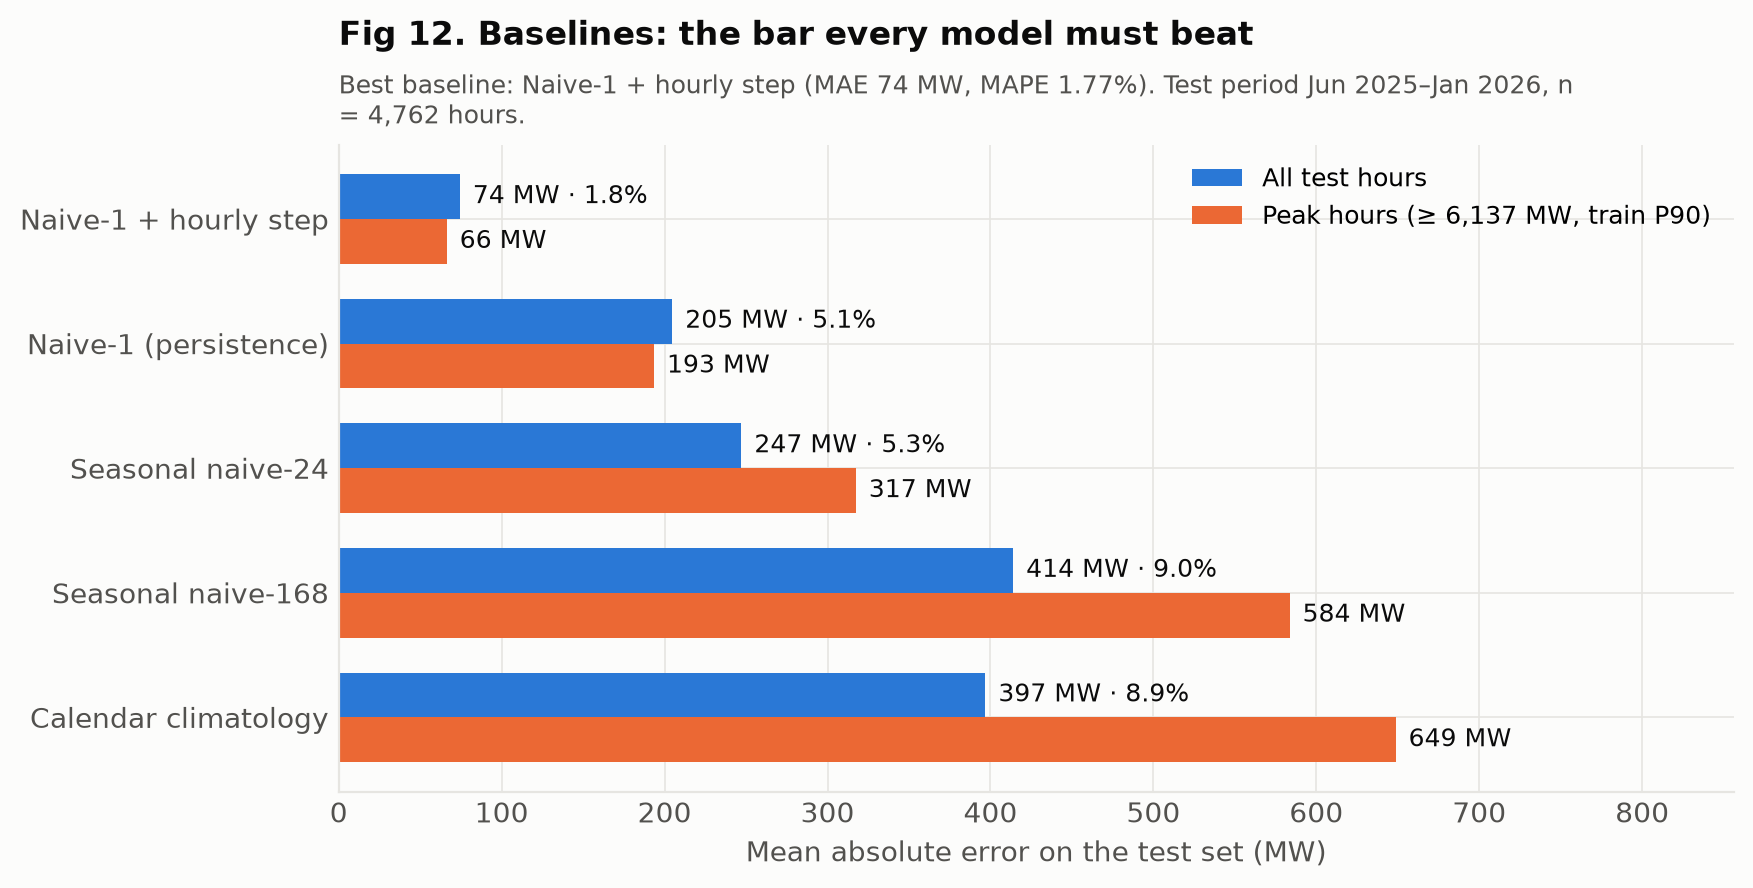

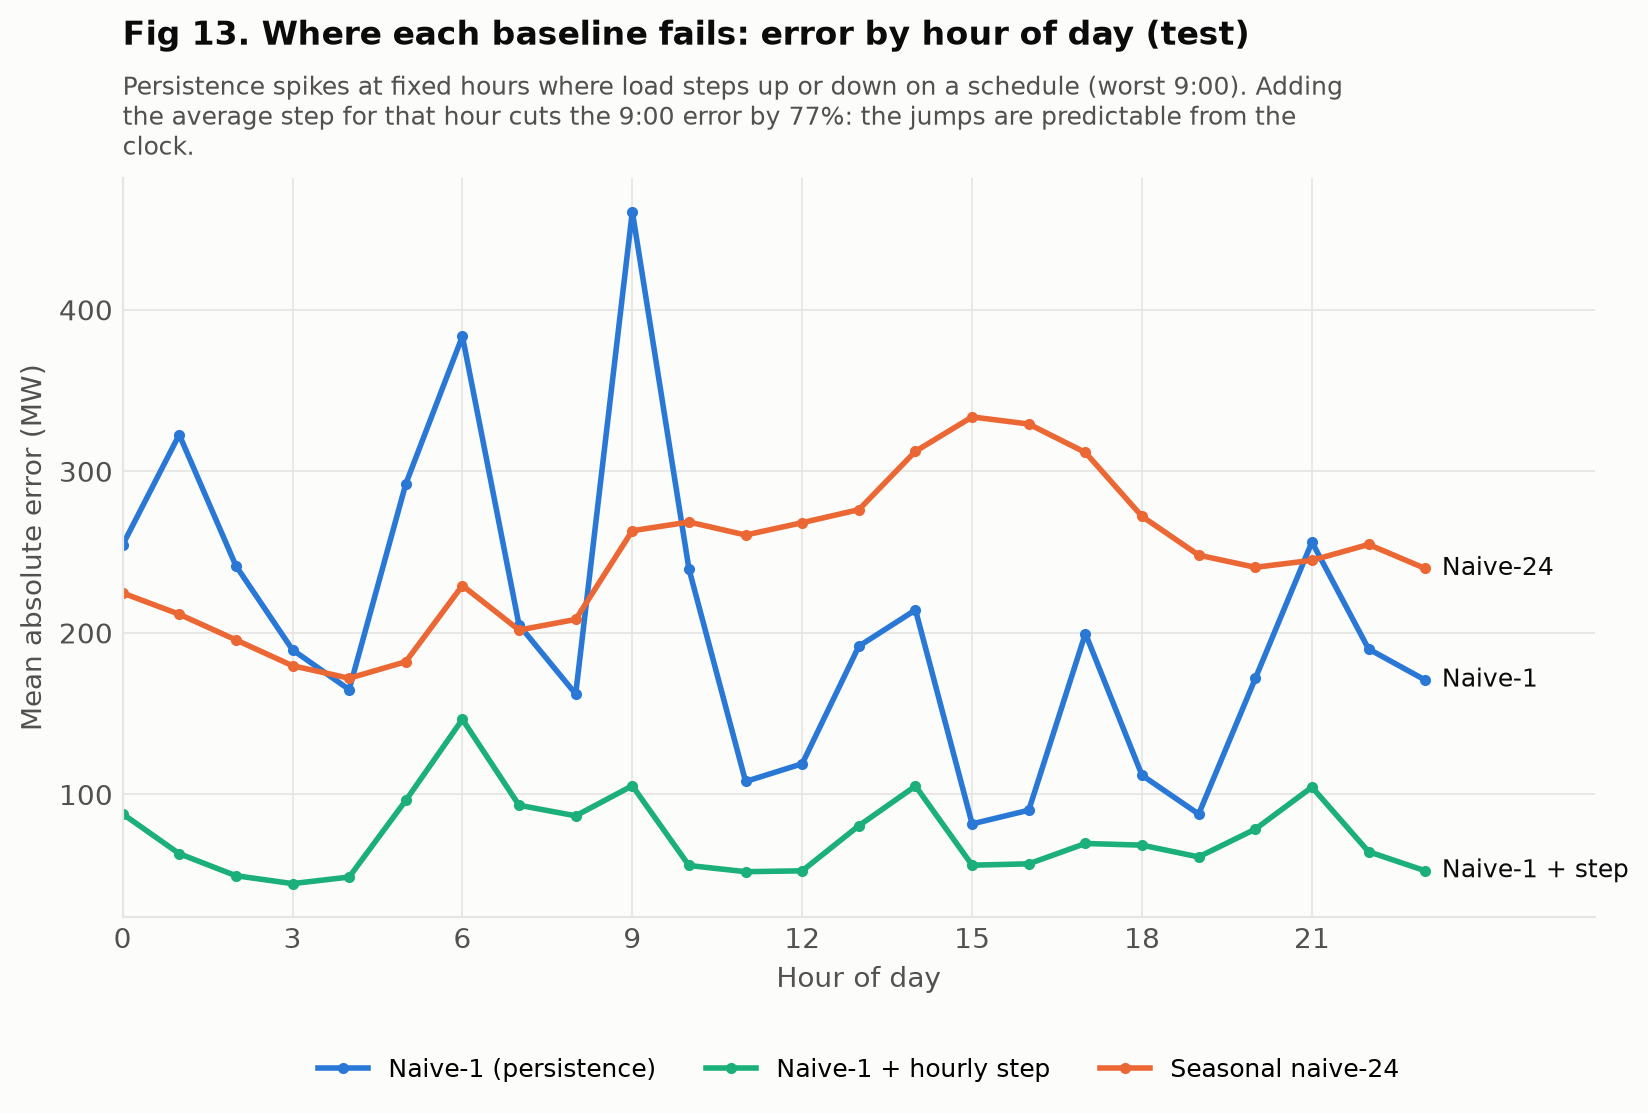

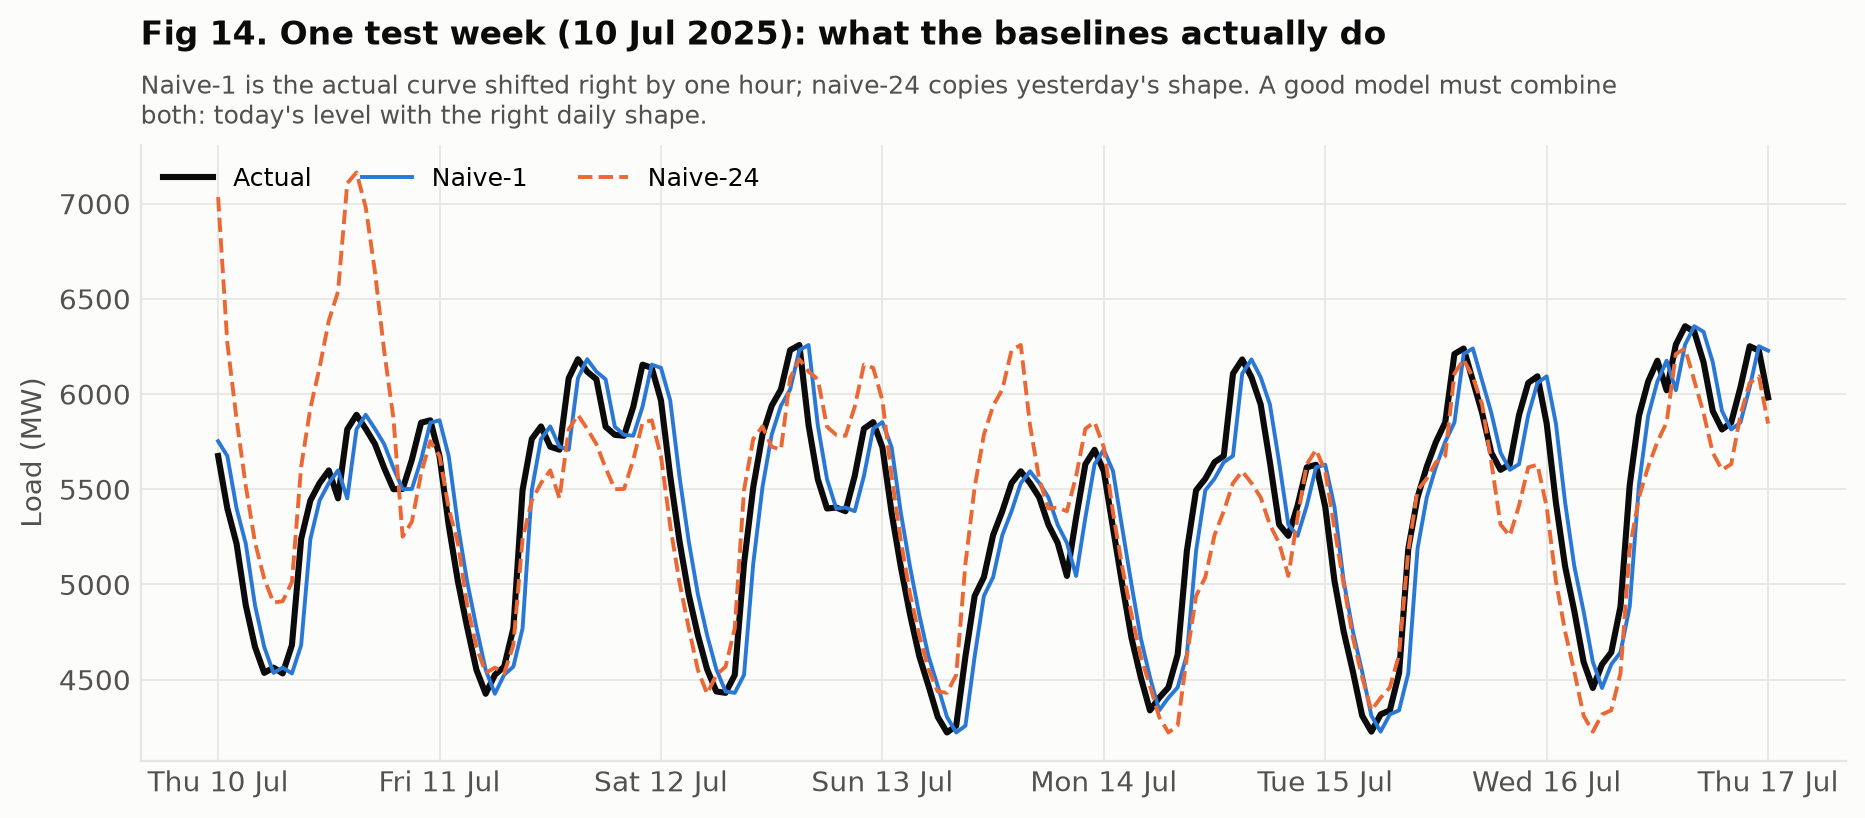

Residual autocorrelation: lag1 = 0.48, lag2 = 0.24, lag24 = 0.39


In [3]:
print("\n" + "=" * 88)
print("PHASE 3 — BASELINES")
print("=" * 88)

from src import baselines, config, data, evaluation as ev, features, split
from src.metrics import evaluate
pd.set_option('display.precision', 2)

def show(name, width=900):
    display(Image(filename=str(config.FIG_DIR / f'{name}.png'), width=width))
hourly = data.load_clean()
feats = features.build_features(hourly)
sp = split.chronological_split(feats)
T = config.TARGET
print(f'Val : {sp.val.index.min():%d %b %Y} → {sp.val.index.max():%d %b %Y}  ({len(sp.val):,} h)')
print(f'Test: {sp.test.index.min():%d %b %Y} → {sp.test.index.max():%d %b %Y}  ({len(sp.test):,} h)')
print(inspect.getsource(evaluate))
print(baselines.NAIVE)
for name, k in [('Naive-1 (persistence)', 1), ('Seasonal naive-24', 24), ('Seasonal naive-168', 168)]:
    same = np.allclose(baselines.naive_forecasts(sp.test)[name], hourly['load_mw'].shift(k).reindex(sp.test.index))
    print(f'{name:24s} equals y(h-{k}) from raw series: {same}')
pd.read_csv(config.TABLE_DIR / 'phase3_v1_offbyone.csv')
print(inspect.getsource(baselines.CalendarClimatology))

def step_table(part):
    d = part[T] - part['load_lag_1']
    return d.groupby(part['hour']).agg(['mean', 'std'])
st = pd.concat({'train': step_table(sp.train), 'test': step_table(sp.test)}, axis=1).round(0)
st.T
print(inspect.getsource(baselines.PersistencePlusStep))
tab = pd.read_csv(config.TABLE_DIR / 'phase3_baselines.csv')
cols = ['model', 'MAE', 'RMSE', 'MAPE', 'R2', 'Bias', 'skill_vs_naive1']
for s in ['val', 'test']:
    print(f'\n{s.upper()} — all hours')
    display(tab[(tab.split == s) & (tab.subset == 'all')][cols].sort_values('MAE').reset_index(drop=True))
print('TEST — peak hours (load ≥ train 90th percentile)')
display(tab[(tab.split == 'test') & (tab.subset == 'peak')][['model', 'n', 'MAE', 'MAPE', 'Bias']].sort_values('MAE').reset_index(drop=True))
show('F12_baselines_mae')
show('F13_baselines_by_hour')
show('F14_baselines_week', 1000)
from statsmodels.tsa.stattools import acf
m = baselines.PersistencePlusStep().fit(sp.dev)
resid = sp.test[T] - m.predict(sp.test)
full = resid.reindex(pd.date_range(resid.index.min(), resid.index.max(), freq='h')).interpolate()
r_acf = acf(full, nlags=24, fft=True)
print(f'Residual autocorrelation: lag1 = {r_acf[1]:.2f}, lag2 = {r_acf[2]:.2f}, lag24 = {r_acf[24]:.2f}')
pd.Series({c: np.corrcoef(sp.test[c], resid)[0, 1] for c in ['load_ramp_1', 'load_lag_1', 'load_lag_24', 'temp_lag_1', 'is_festival']}).round(3).to_frame('corr with residual').T
import inspect
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
from IPython.display import Image, display

## Phase 4 — Ridge / Lasso



PHASE 4 — RIDGE / LASSO
Base design: (19047, 47) | with hour×month: (19047, 309)
def pipe(model) -> Pipeline:
    return Pipeline([("scaler", StandardScaler()), ("model", model)])

def make_model(kind: str, alpha: float | None = None):
    if kind == "ols":
        return LinearRegression()
    if kind == "ridge":
        return Ridge(alpha=alpha)
    if kind == "lasso":
        return Lasso(alpha=alpha, max_iter=20000, tol=1e-4)
    raise ValueError(kind)

ols  : max |sklearn − closed form| = 8.82e-11
ridge: max |sklearn − closed form| = 3.16e-11
def cv_curve(X: pd.DataFrame, y: pd.Series, kind: str, alphas, n_splits: int = N_SPLITS) -> pd.DataFrame:
    """Forward-chaining CV: fold k trains on everything before its validation block.
    Returns one row per (alpha, fold) with validation MSE and MAE."""
    tscv = TimeSeriesSplit(n_splits=n_splits)
    rows = []
    for fold, (tr, va) in enumerate(tscv.split(X)):
        m = pipe(make_model(kind, alphas[0]))
        if kind == "lasso"

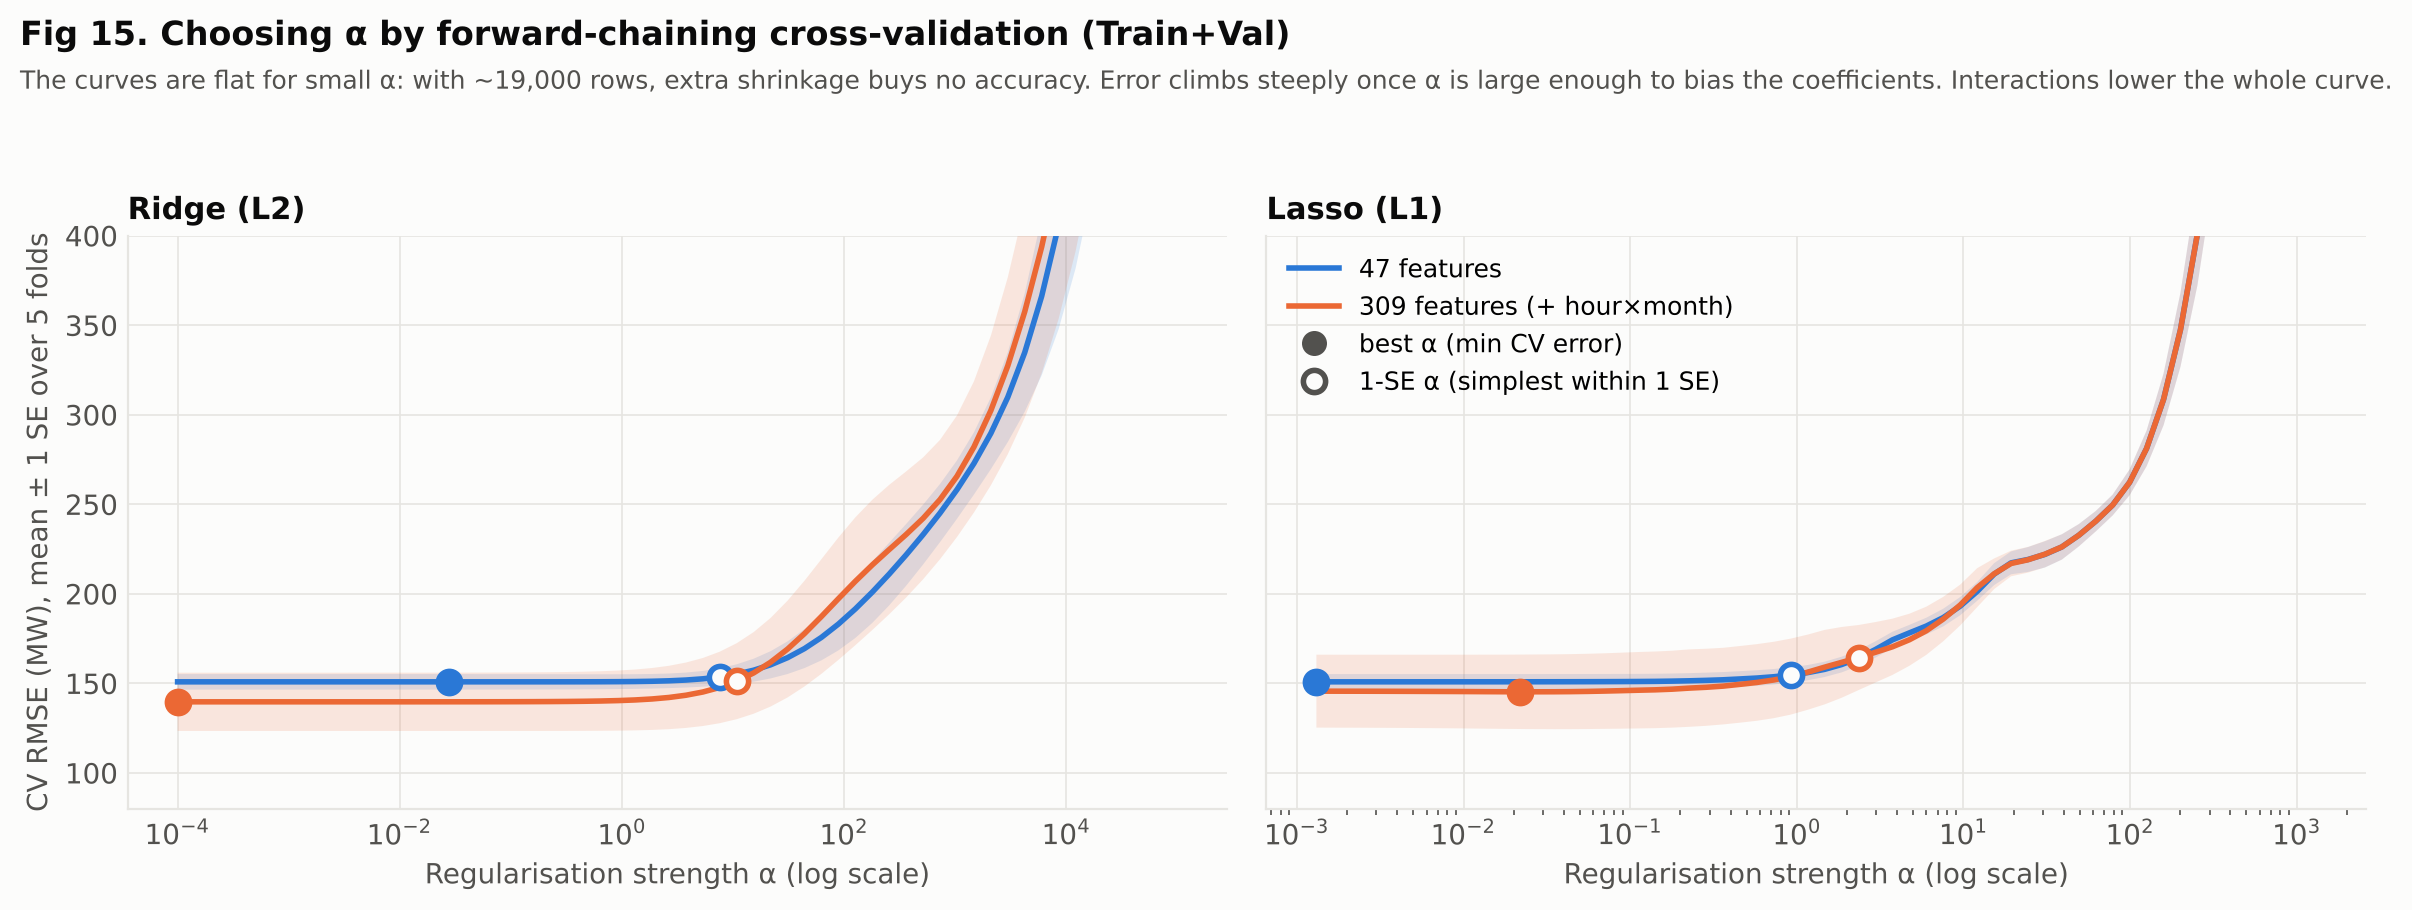

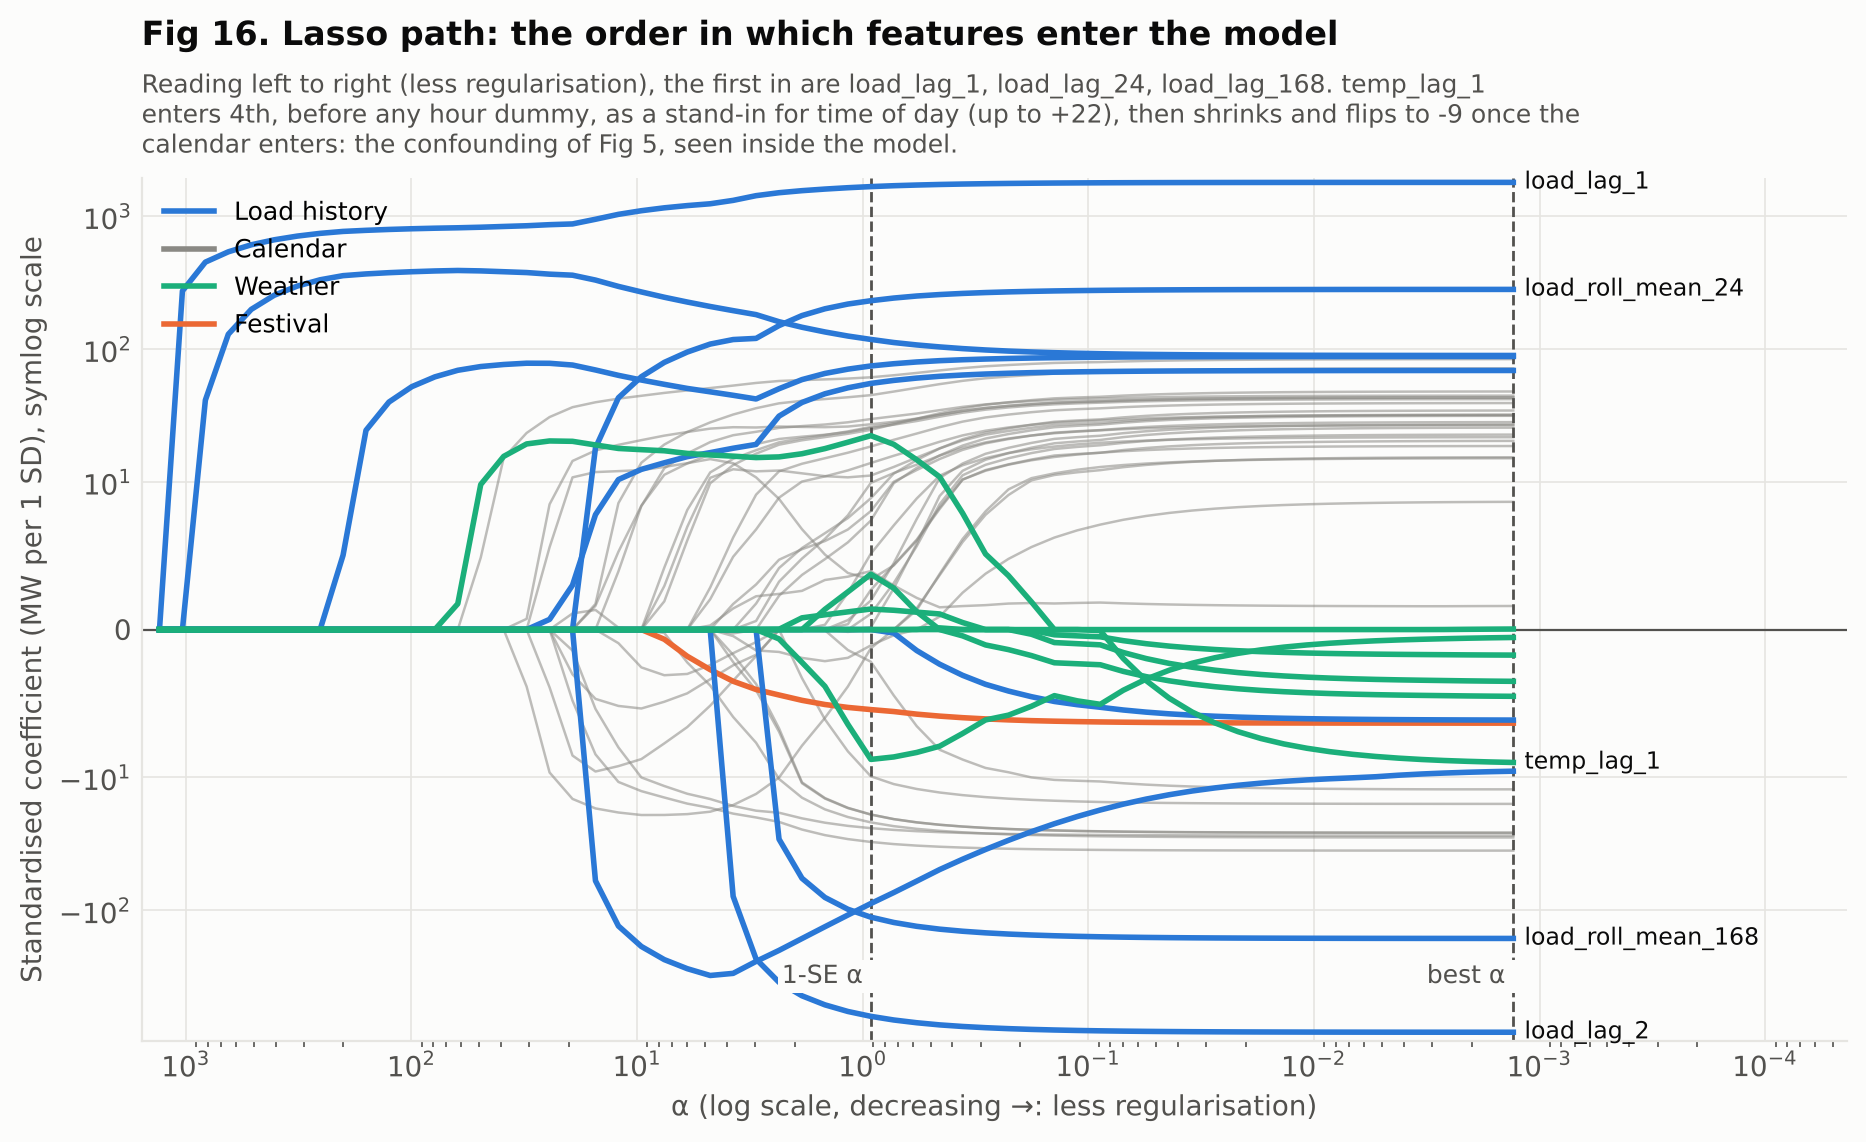

def window_bias_variance(X, y, alphas, cols, days: int = 30) -> pd.DataFrame:
    """Fair stability test: fit on consecutive EQUAL-SIZE windows of `days` days and forecast the
    next window. For each alpha (0 = OLS):
      coef_spread = sum over `cols` of the std of the standardised coefficient across windows (variance)
      next_mae    = mean MAE on the following window (what the variance/bias mix costs in accuracy)
    Equal sizes matter: with expanding windows a fixed alpha shrinks small windows more, which would
    confound shrinkage with variance."""
    n = days * 24
    k = len(X) // n
    idx = [X.columns.get_loc(c) for c in cols]
    rows = []
    for a in alphas:
        kind = "ols" if a == 0 else "ridge"
        co, err = [], []
        for i in range(k - 1):
            tr, te = slice(i * n, (i + 1) * n), slice((i + 1) * n, min((i + 2) * n, len(X)))
            m = fit_final(X.iloc[tr], y.iloc[tr], kind, None if a == 0 else a)
            co.append(m.named_steps["model

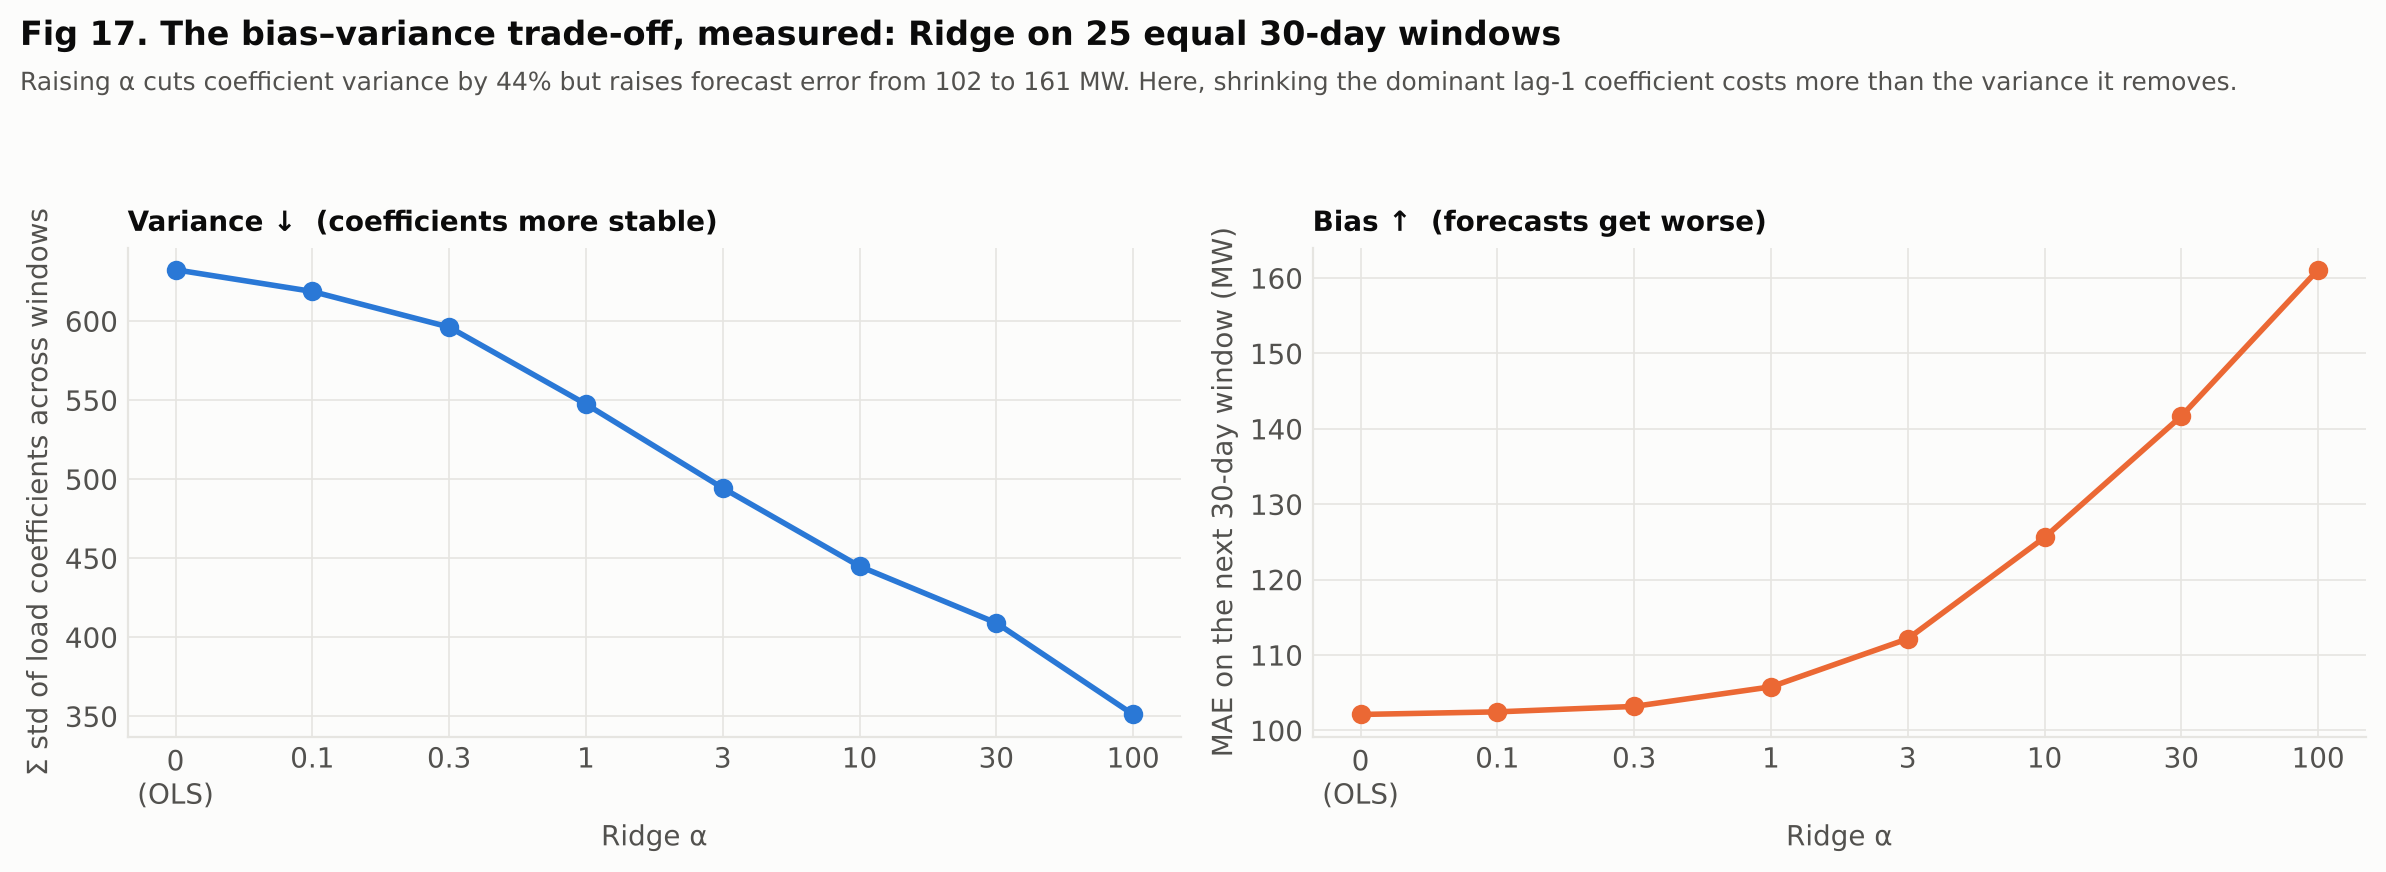

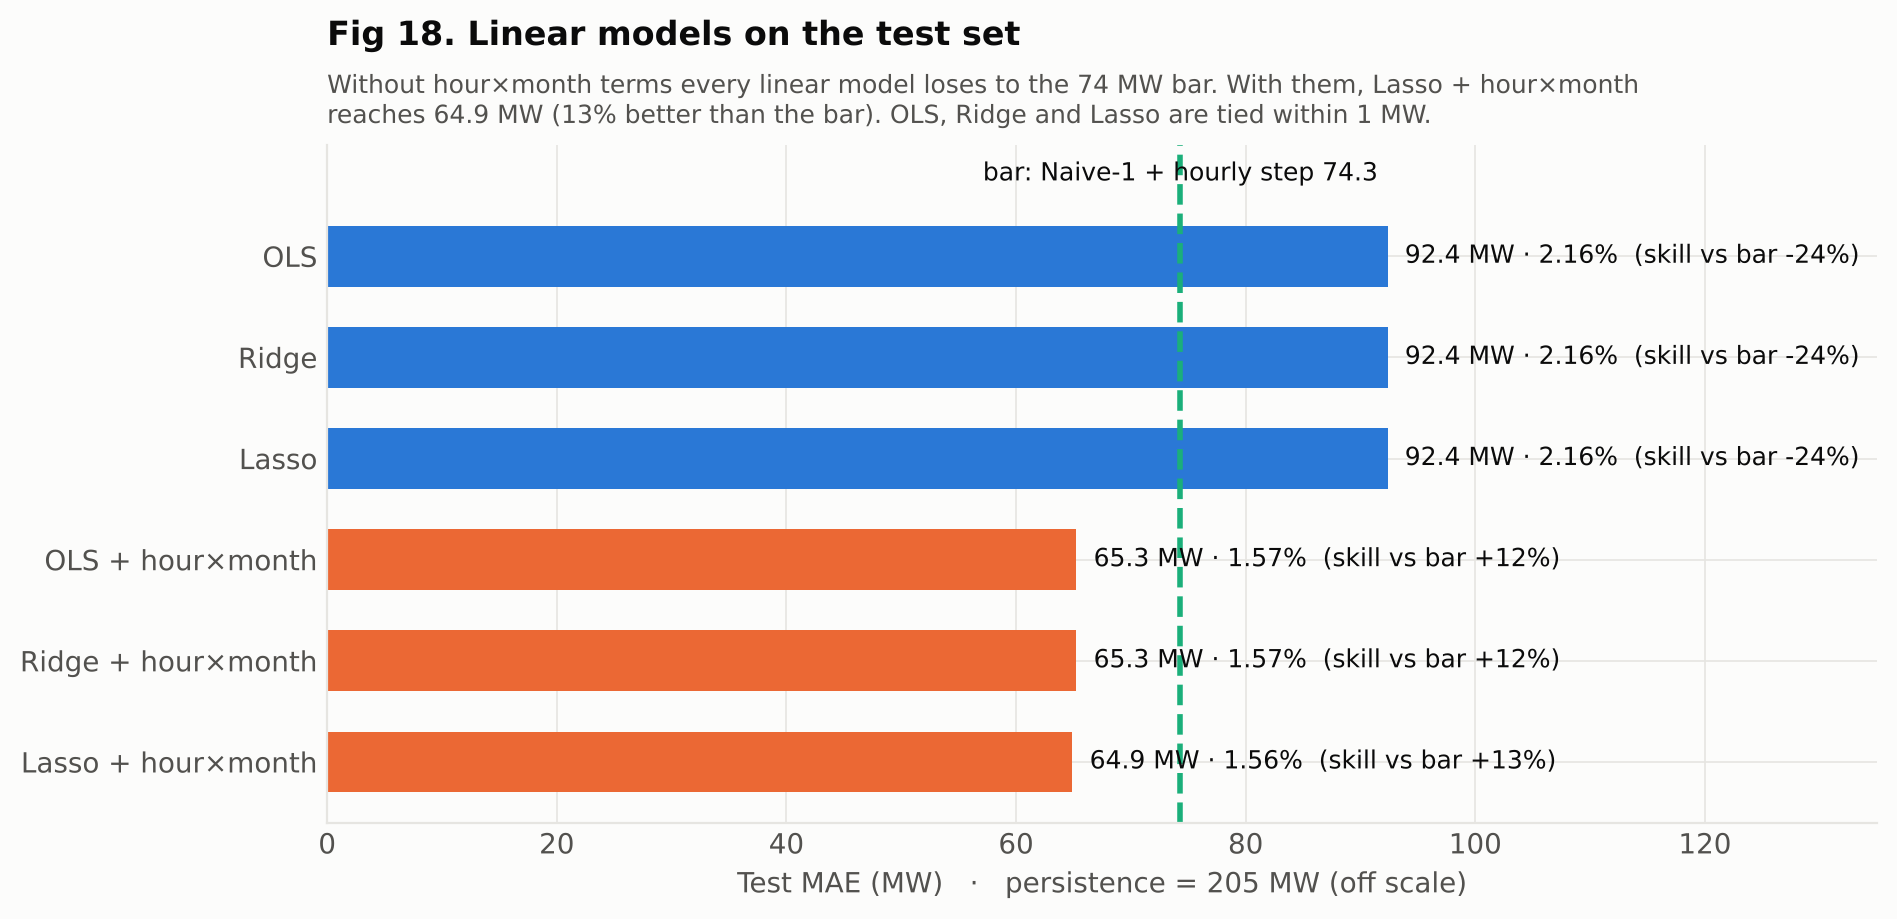

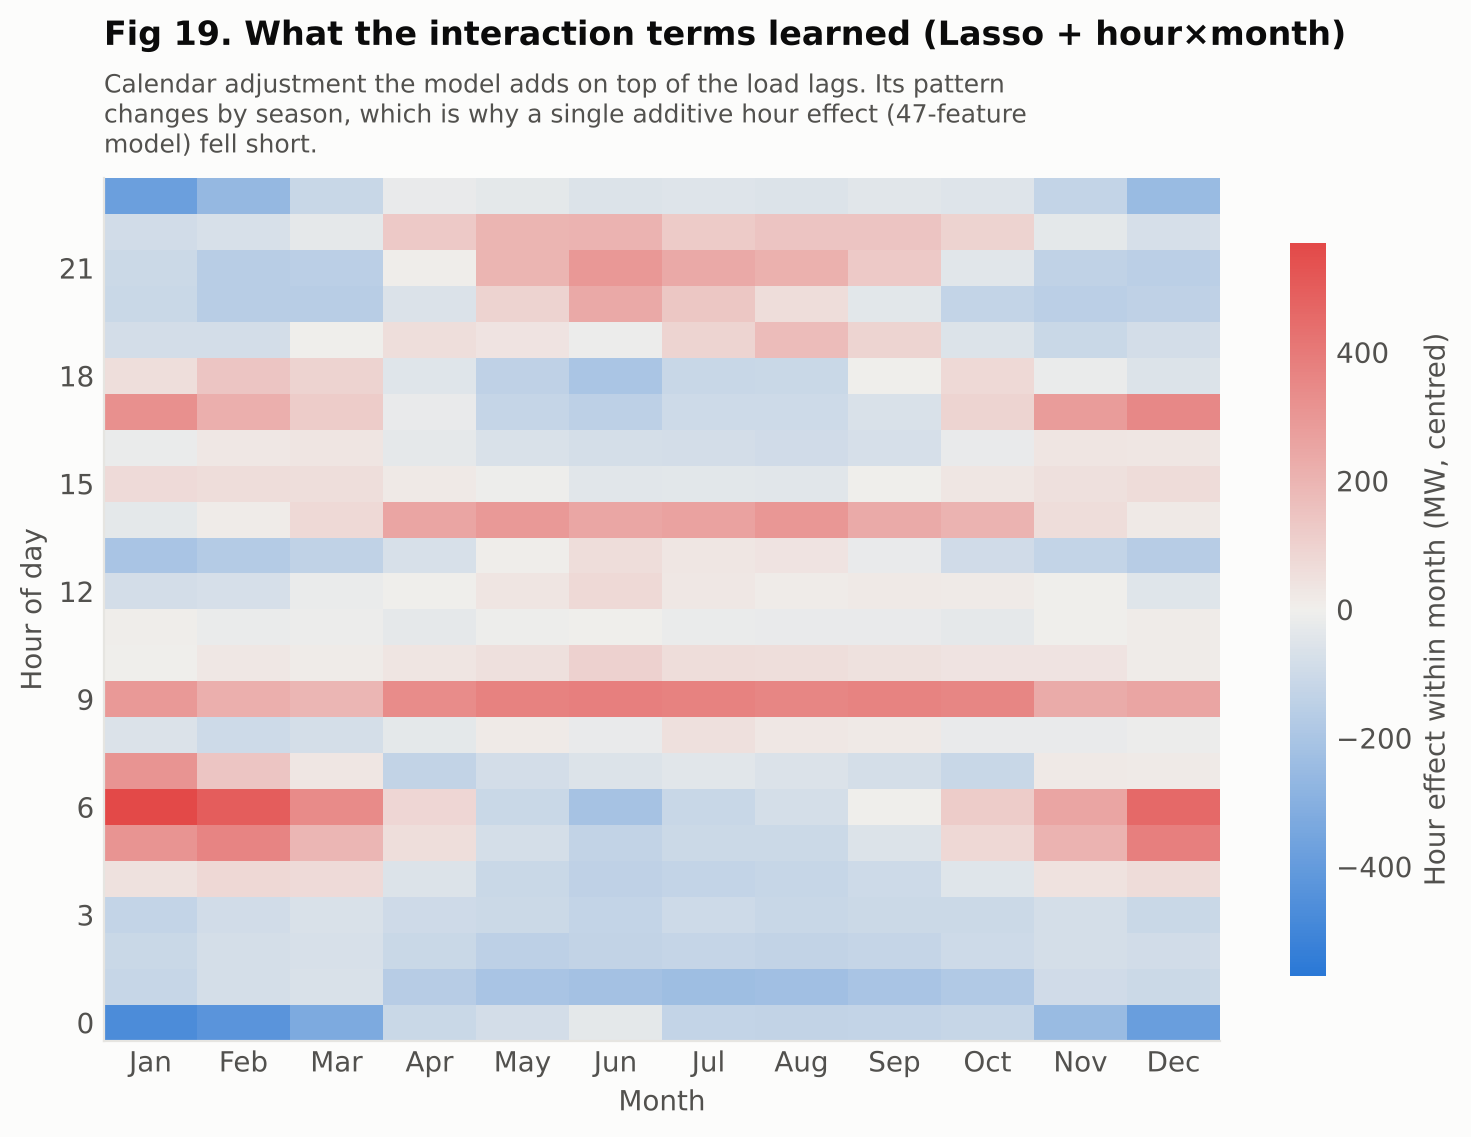

In [4]:
print("\n" + "=" * 88)
print("PHASE 4 — RIDGE / LASSO")
print("=" * 88)

from src import config, data, features, split, linear_models as lm
pd.set_option('display.precision', 3)
sp = split.chronological_split(features.build_features(data.load_clean()))
T = config.TARGET
X_dev = features.linear_design(sp.dev, False)
print('Base design:', X_dev.shape, '| with hour×month:', features.linear_design(sp.dev, True).shape)
print(inspect.getsource(lm.pipe))
print(inspect.getsource(lm.make_model))
X = features.linear_design(sp.train, False).astype(float).values
Xs = (X - X.mean(0)) / X.std(0)
y = sp.train[T].values
yc = y - y.mean()
for kind, a in [('ols', None), ('ridge', 50.0)]:
    m = lm.fit_final(features.linear_design(sp.train, False), sp.train[T], kind, a)
    A = Xs.T @ Xs + (0 if a is None else a) * np.eye(Xs.shape[1])
    b = np.linalg.solve(A, Xs.T @ yc)
    print(f"{kind:5s}: max |sklearn − closed form| = {np.abs(m.named_steps['model'].coef_ - b).max():.2e}")
print(inspect.getsource(lm.cv_curve))
print(inspect.getsource(lm.select_alpha))
pd.read_csv(config.TABLE_DIR / 'phase4_alphas.csv')
show('F15_cv_alpha_curves')
show('F16_lasso_path')
c = pd.read_csv(config.TABLE_DIR / 'phase4_coefficients_std.csv', index_col=0)
rows = []
for m in ['Lasso', 'Lasso (1-SE α)', 'Lasso + hour×month', 'Lasso + hour×month (1-SE α)']:
    s = c[m].dropna()
    nz = s.abs() > 1e-09
    rows.append({'model': m, 'non-zero': f'{nz.sum()}/{len(s)}', 'weather kept': ', '.join((w for w in features.WEATHER if nz.get(w, False))) or 'none'})
pd.DataFrame(rows)
c.loc[features.WEATHER, ['OLS', 'Lasso', 'Lasso (1-SE α)']].round(2)
print(inspect.getsource(lm.window_bias_variance))
pd.read_csv(config.TABLE_DIR / 'phase4_bias_variance.csv')
show('F17_bias_variance')
tab = pd.read_csv(config.TABLE_DIR / 'phase4_linear.csv')
cols = ['model', 'MAE', 'RMSE', 'MAPE', 'R2', 'Bias', 'skill_vs_naive1', 'skill_vs_step']
tab[(tab.split == 'test') & (tab.subset == 'all')][cols].sort_values('MAE').reset_index(drop=True)
show('F18_linear_results')
show('F19_learned_hour_month', 800)
tab[(tab.split == 'test') & (tab.subset == 'peak')][['model', 'n', 'MAE', 'MAPE', 'Bias']].sort_values('MAE').reset_index(drop=True)
import inspect
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
from IPython.display import Image, display

## Phase 5 — Tree Models



PHASE 5 — TREE MODELS
28 tree features: ['hour', 'dow', 'month', 'dayofyear', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'is_weekend', 'is_festival', 'load_lag_1', 'load_lag_2', 'load_lag_3', 'load_lag_24', 'load_lag_48', 'load_lag_168', 'load_roll_mean_24', 'load_roll_std_24', 'load_roll_mean_168', 'load_ramp_1', 'temp_lag_1', 'humidity_lag_1', 'temp_roll_mean_24', 'weather_lag_1_cloudy', 'weather_lag_1_rain', 'weather_lag_1_storm']
class TargetMode(BaseEstimator, RegressorMixin):
    """Wraps a regressor so that the target can be the level or the hourly change.
    Behaves like a normal sklearn estimator, so `target` can be tuned in a CV search."""

    def __init__(self, regressor=None, target: str = "level"):
        self.regressor = regressor
        self.target = target

    def fit(self, X, y):
        self.regressor_ = clone(self.regressor)
        y_t = y - X[LAG1] if self.target == "delta" else y
        self.regressor_.fit(X, y_t)
        self.f

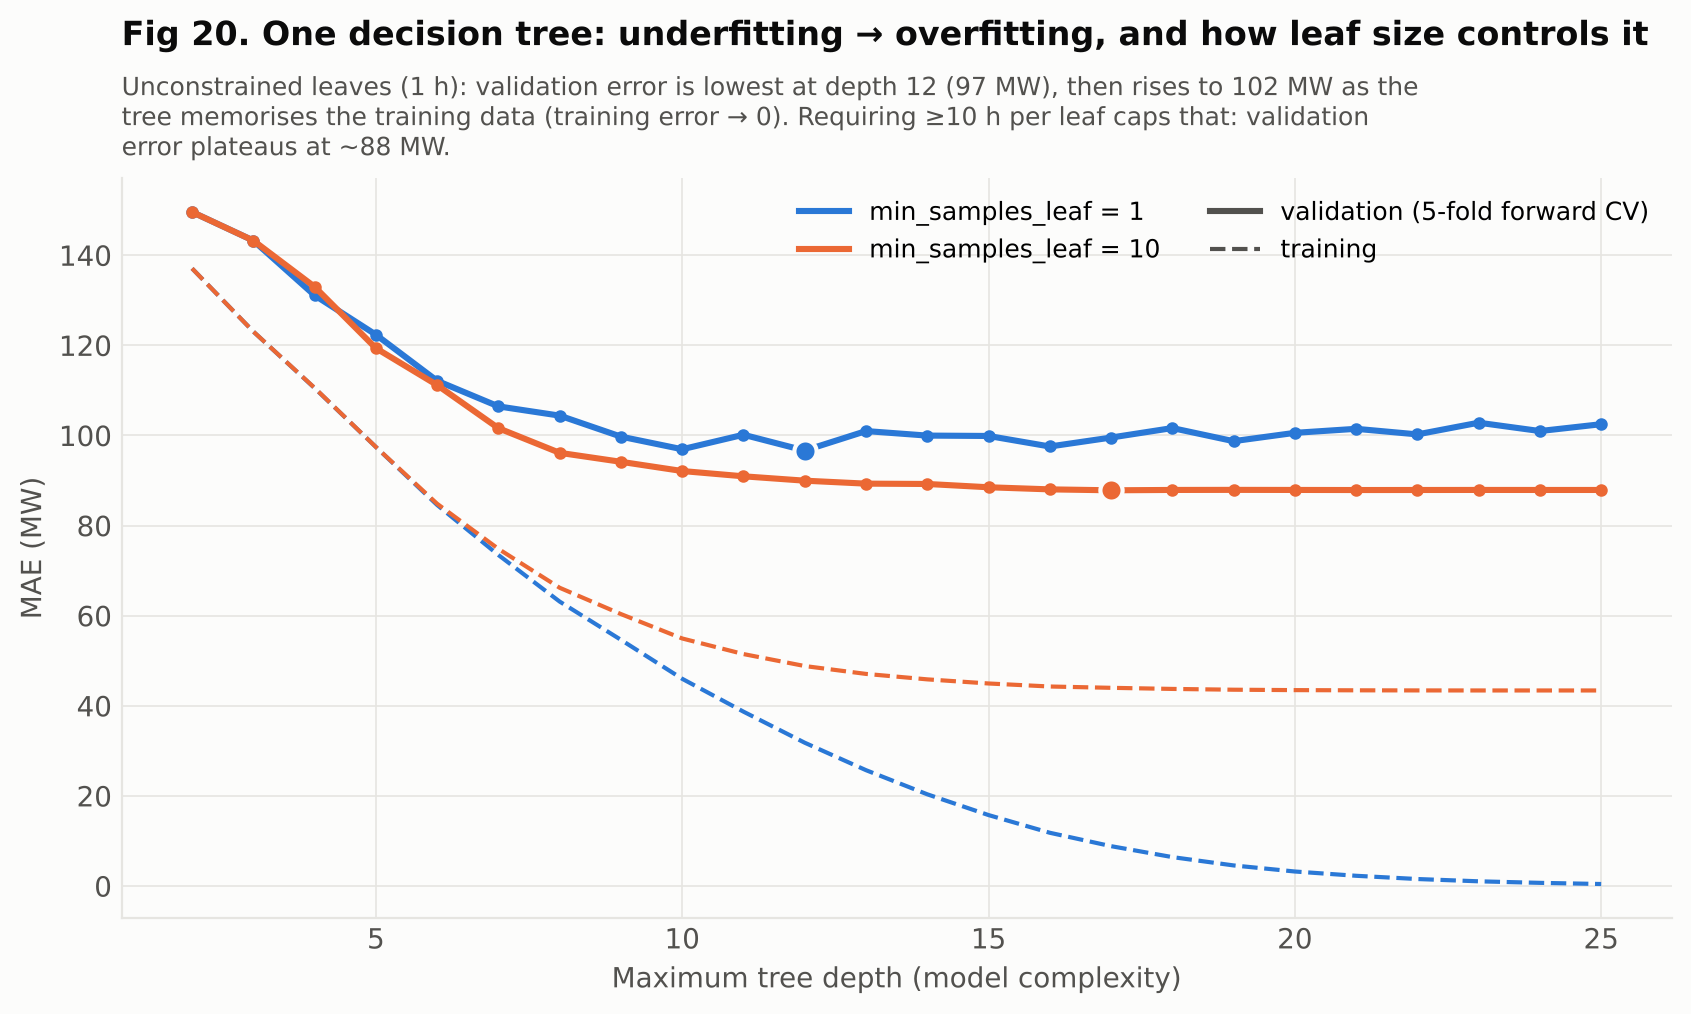

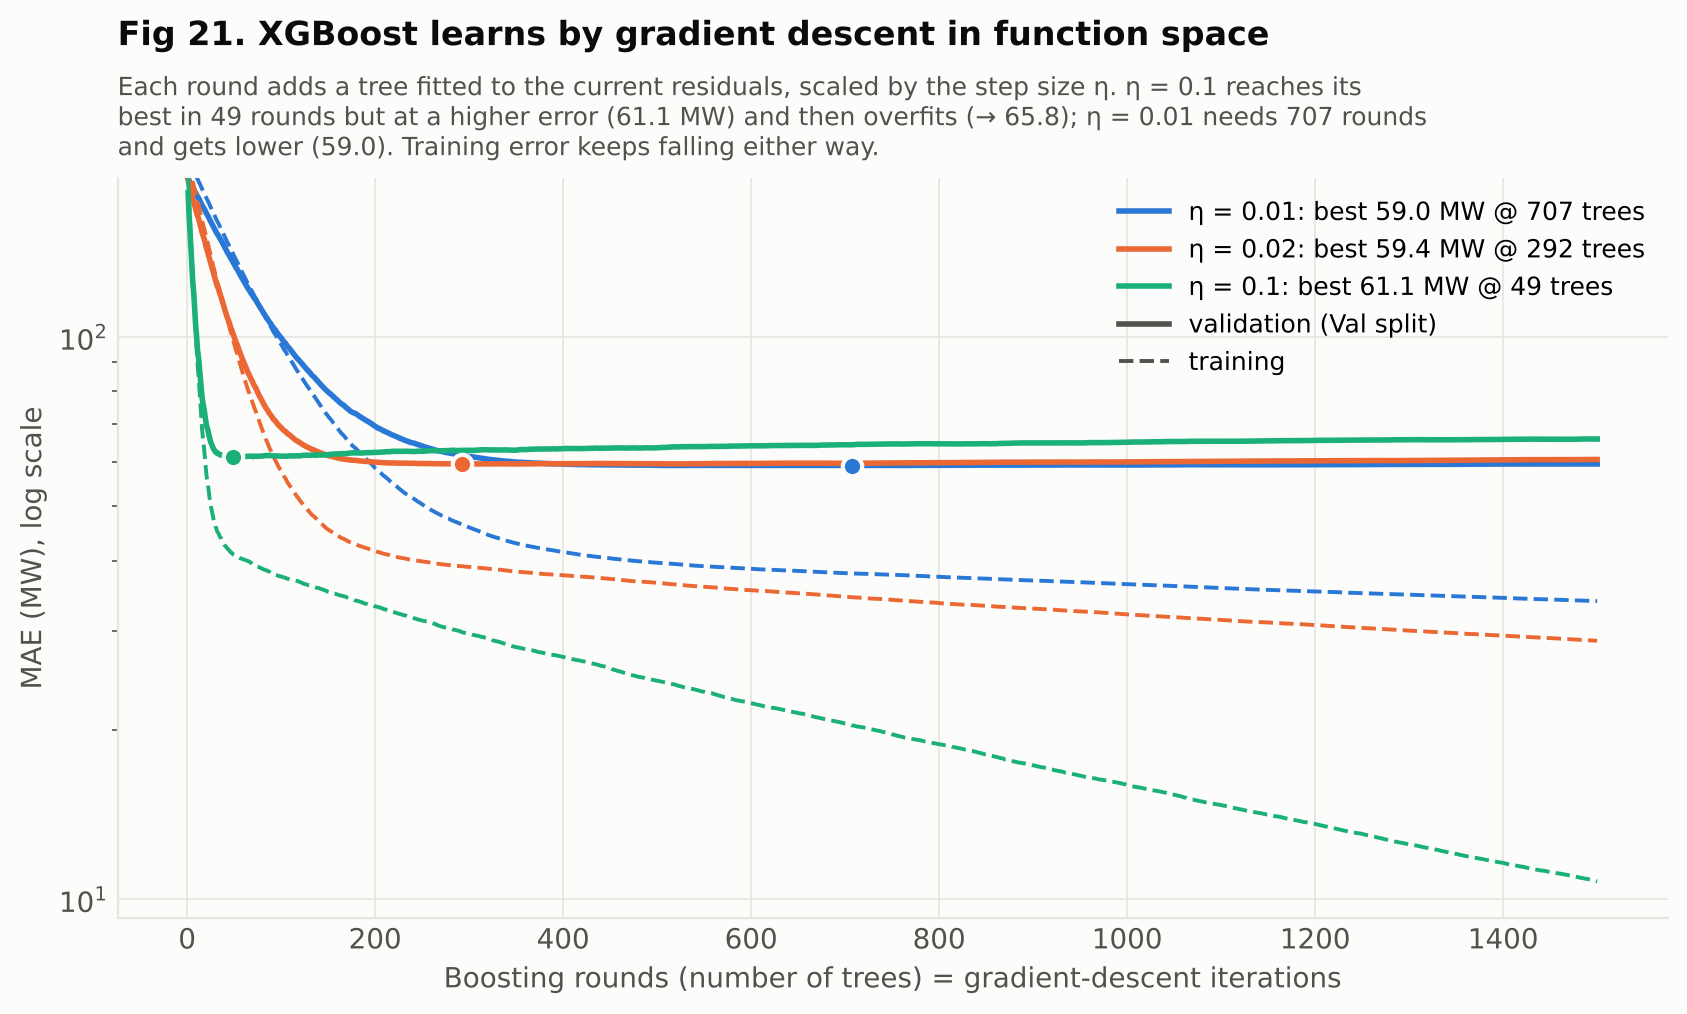

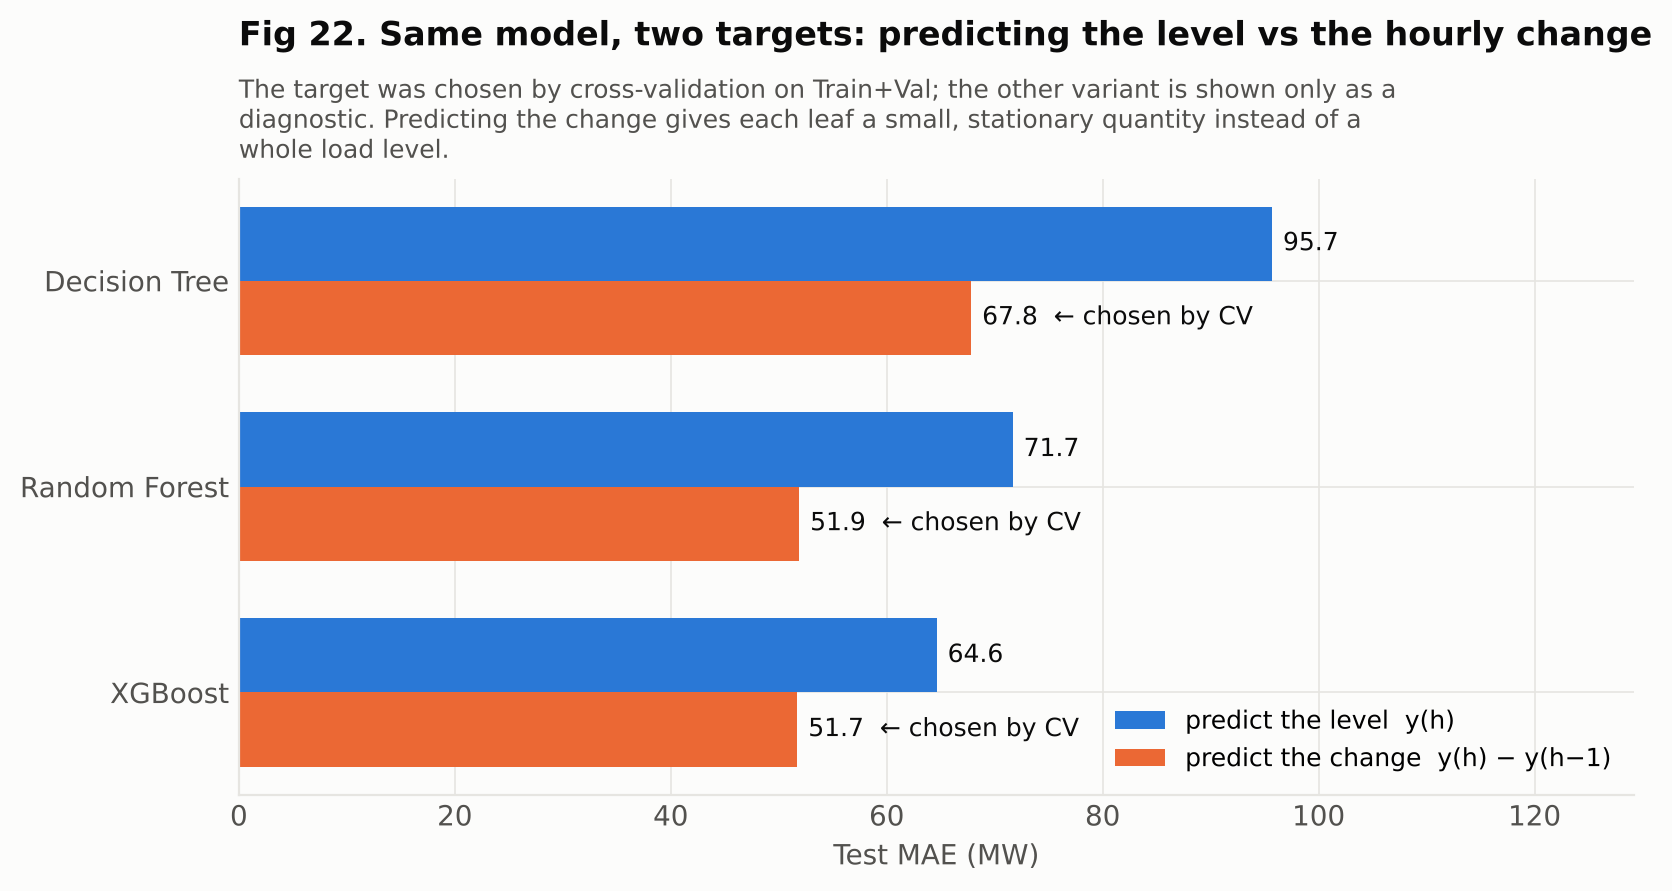

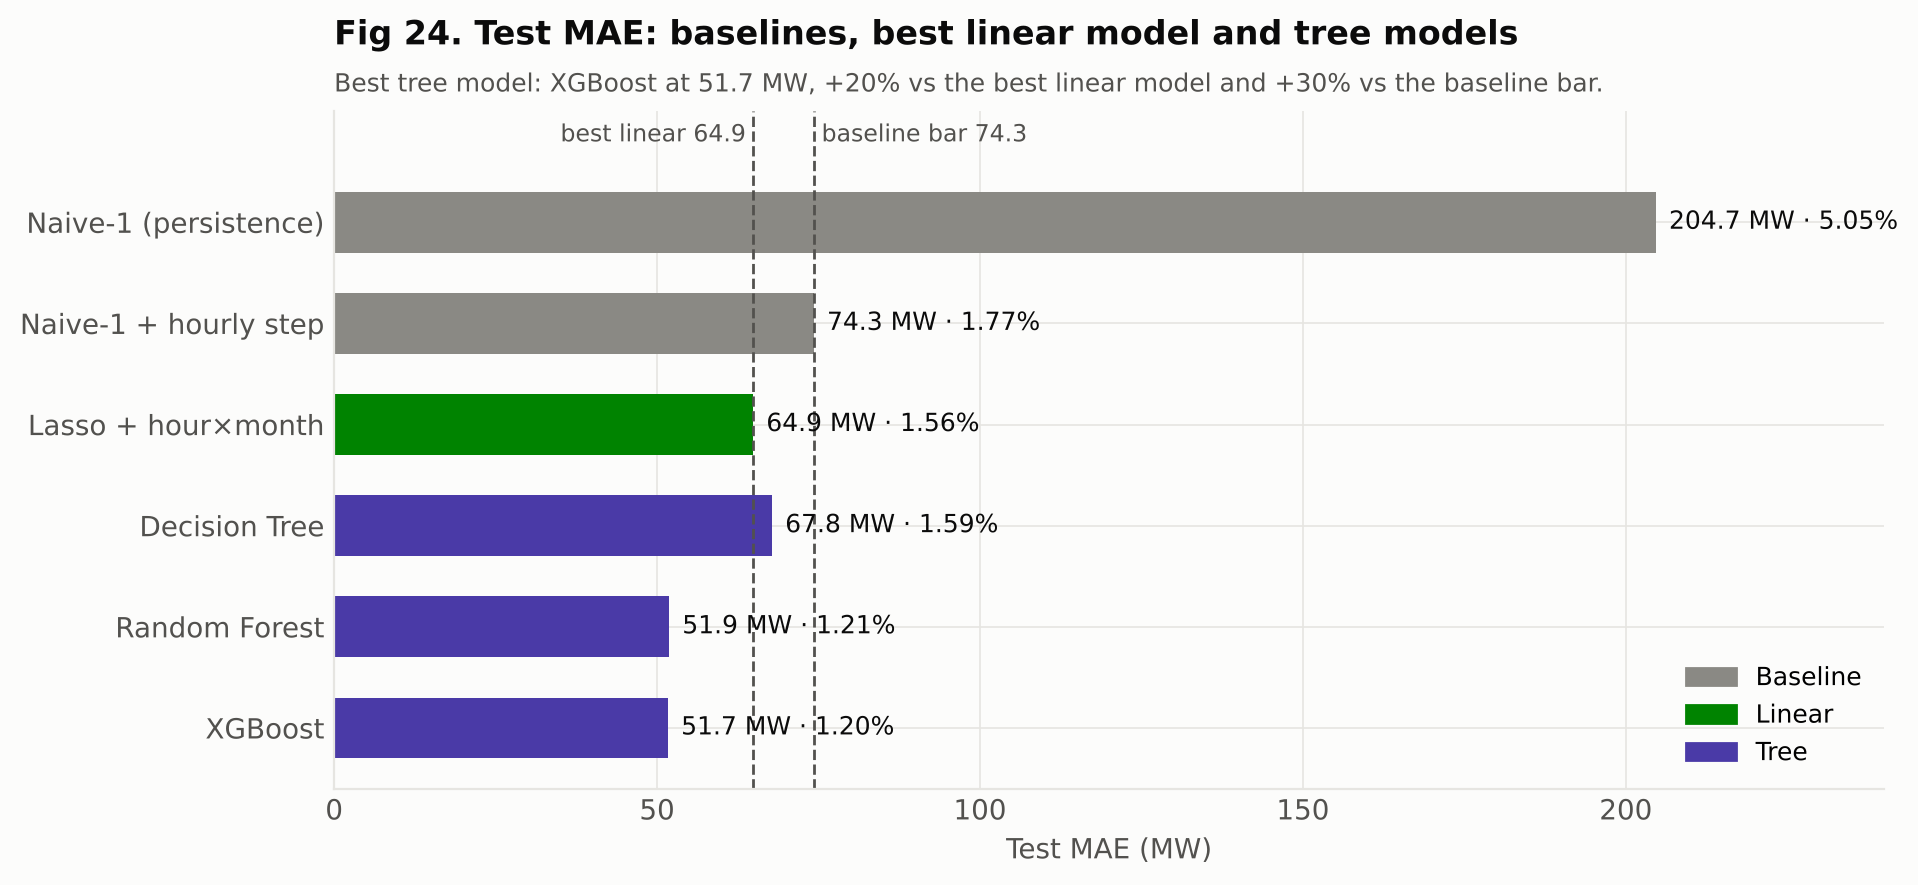

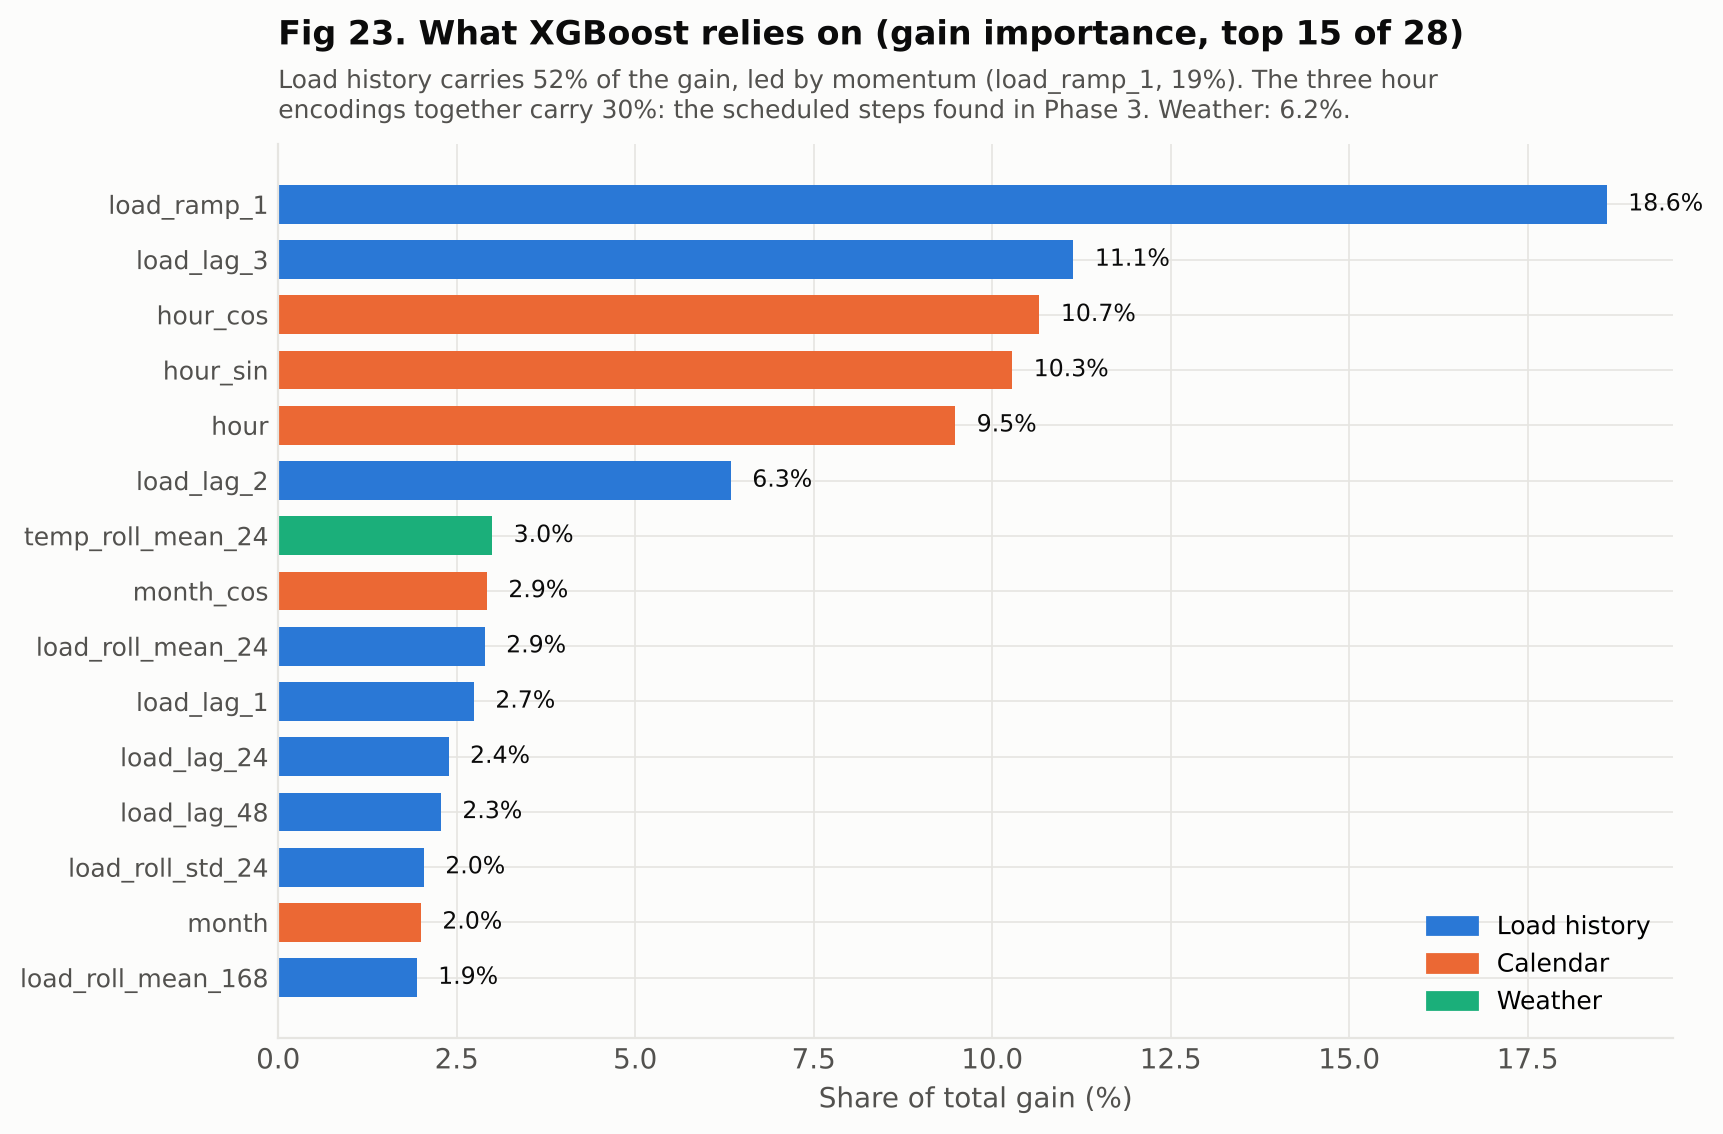

In [5]:
print("\n" + "=" * 88)
print("PHASE 5 — TREE MODELS")
print("=" * 88)

from src import config, data, features, split, tree_models as tm
pd.set_option('display.precision', 3)
sp = split.chronological_split(features.build_features(data.load_clean()))
F = features.FEATURE_SETS['tree']
print(f'{len(F)} tree features:', F)
print(inspect.getsource(tm.TargetMode))
for n, g in tm.SEARCH.items():
    print(n, {k.replace('regressor__', ''): v for k, v in g.items()})
src = (ROOT / 'scripts' / 'run_phase5_refine.py').read_text(encoding='utf-8')
print(src[src.index('STAGE2 = {'):src.index('best1 =')].split('# keep stage-1')[0])
pd.read_csv(config.TABLE_DIR / 'phase5_stage2_log.csv')
pd.read_csv(config.TABLE_DIR / 'phase5_best_params.csv').set_index(['model', 'split']).T
show('F20_tree_depth_sweep')
show('F21_boosting_curve')
tab = pd.read_csv(config.TABLE_DIR / 'phase5_trees.csv')
cols = ['model', 'MAE', 'RMSE', 'MAPE', 'R2', 'Bias', 'skill_vs_naive1', 'skill_vs_step', 'skill_vs_lasso']
tab[(tab.split == 'test') & (tab.subset == 'all')][cols].sort_values('MAE').reset_index(drop=True)
show('F22_level_vs_delta')
show('F24_results_so_far')
tab[(tab.split == 'test') & (tab.subset == 'peak')][['model', 'n', 'MAE', 'MAPE', 'Bias']].sort_values('MAE').reset_index(drop=True)
show('F23_xgb_importance', 800)
imp = pd.read_csv(config.TABLE_DIR / 'phase5_importance.csv', index_col=0)
grp = lambda c: 'Load history' if c in features.LOAD else 'Weather' if c in features.WEATHER else 'Calendar'
imp.groupby(imp.index.map(grp)).sum().round(3)
import pandas as pd
from IPython.display import Image, display

## Phase 7 — Final Evaluation



PHASE 7 — FINAL EVALUATION
Final models: ['Naive-1 (persistence)', 'Naive-1 + hourly step', 'Lasso + hour×month', 'Random Forest', 'XGBoost']


,model,family,MAE,RMSE,MAPE,R2,Bias,skill_vs_step
74,XGBoost,Tree,51.734,76.165,1.204,0.997,1.125,0.304
68,Random Forest,Tree,51.908,76.432,1.208,0.997,1.098,0.301
92,"MLP v4 [64,32] Δ-target",Neural,52.123,76.369,1.215,0.997,1.753,0.299
58,Lasso + hour×month,Linear,64.913,92.030,1.558,0.995,5.077,0.127
18,Naive-1 + hourly step,Baseline,74.313,104.284,1.774,0.994,2.158,0.000
10,Naive-1 (persistence),Baseline,204.685,265.201,5.055,0.959,0.424,-1.754


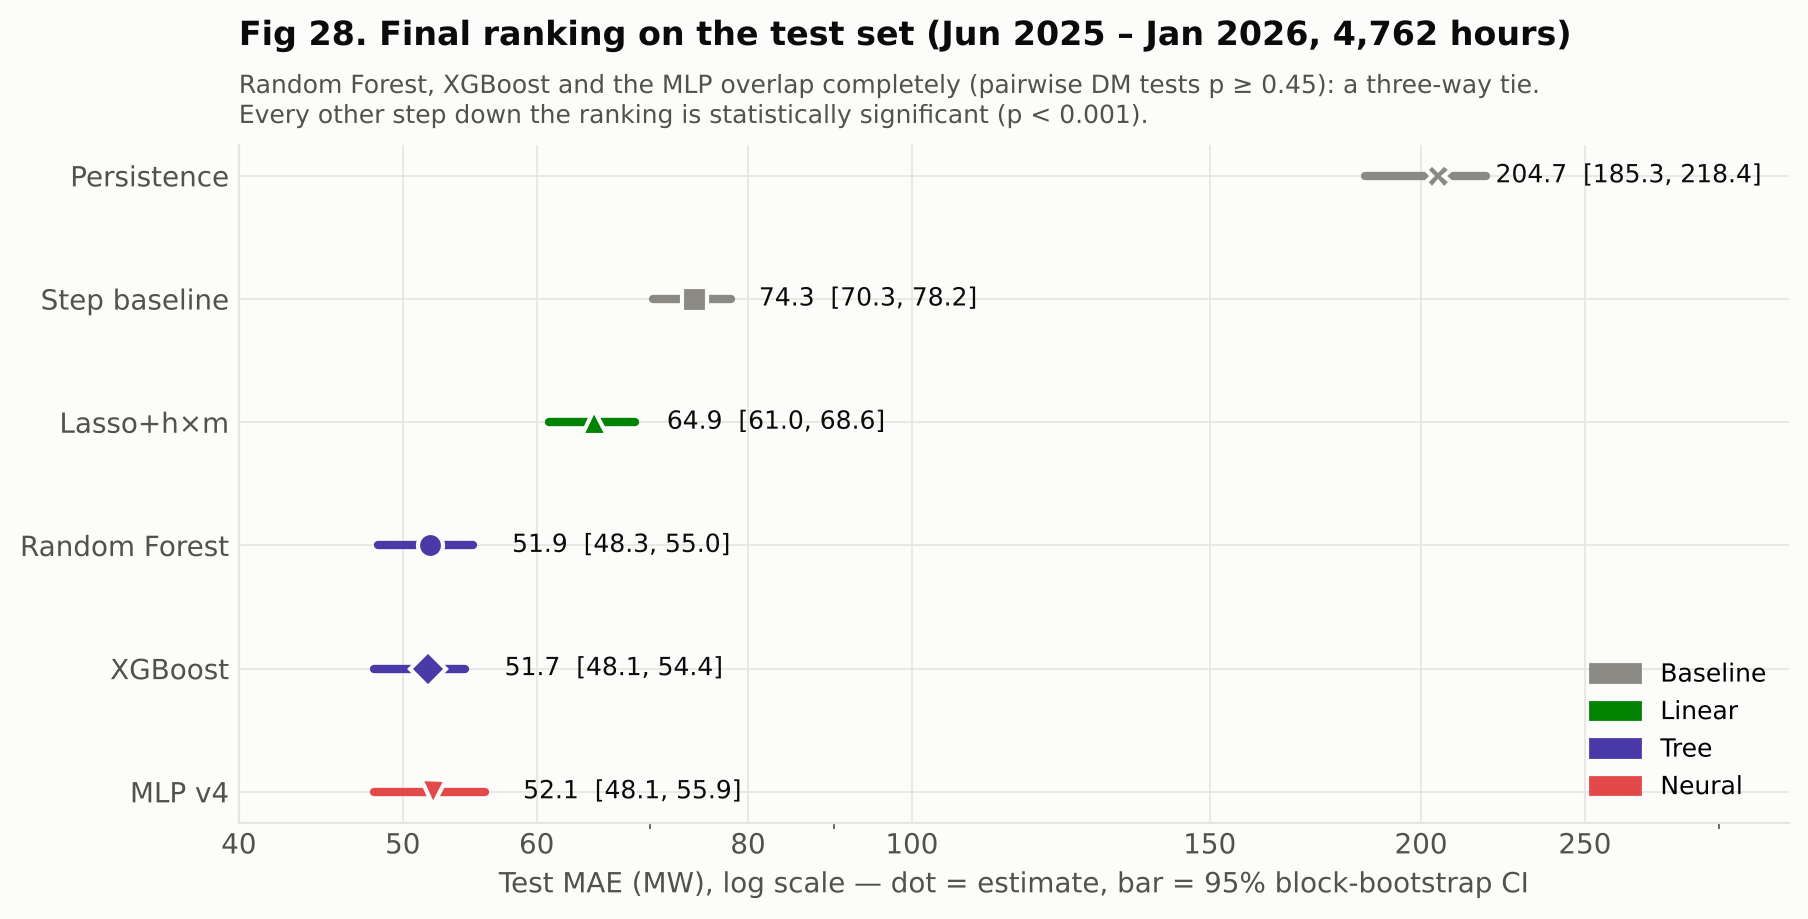

[Warning] Missing MAE gap matrix file: compare_gaps.csv
[Warning] Figure not found: F29_mae_gap_matrix.png


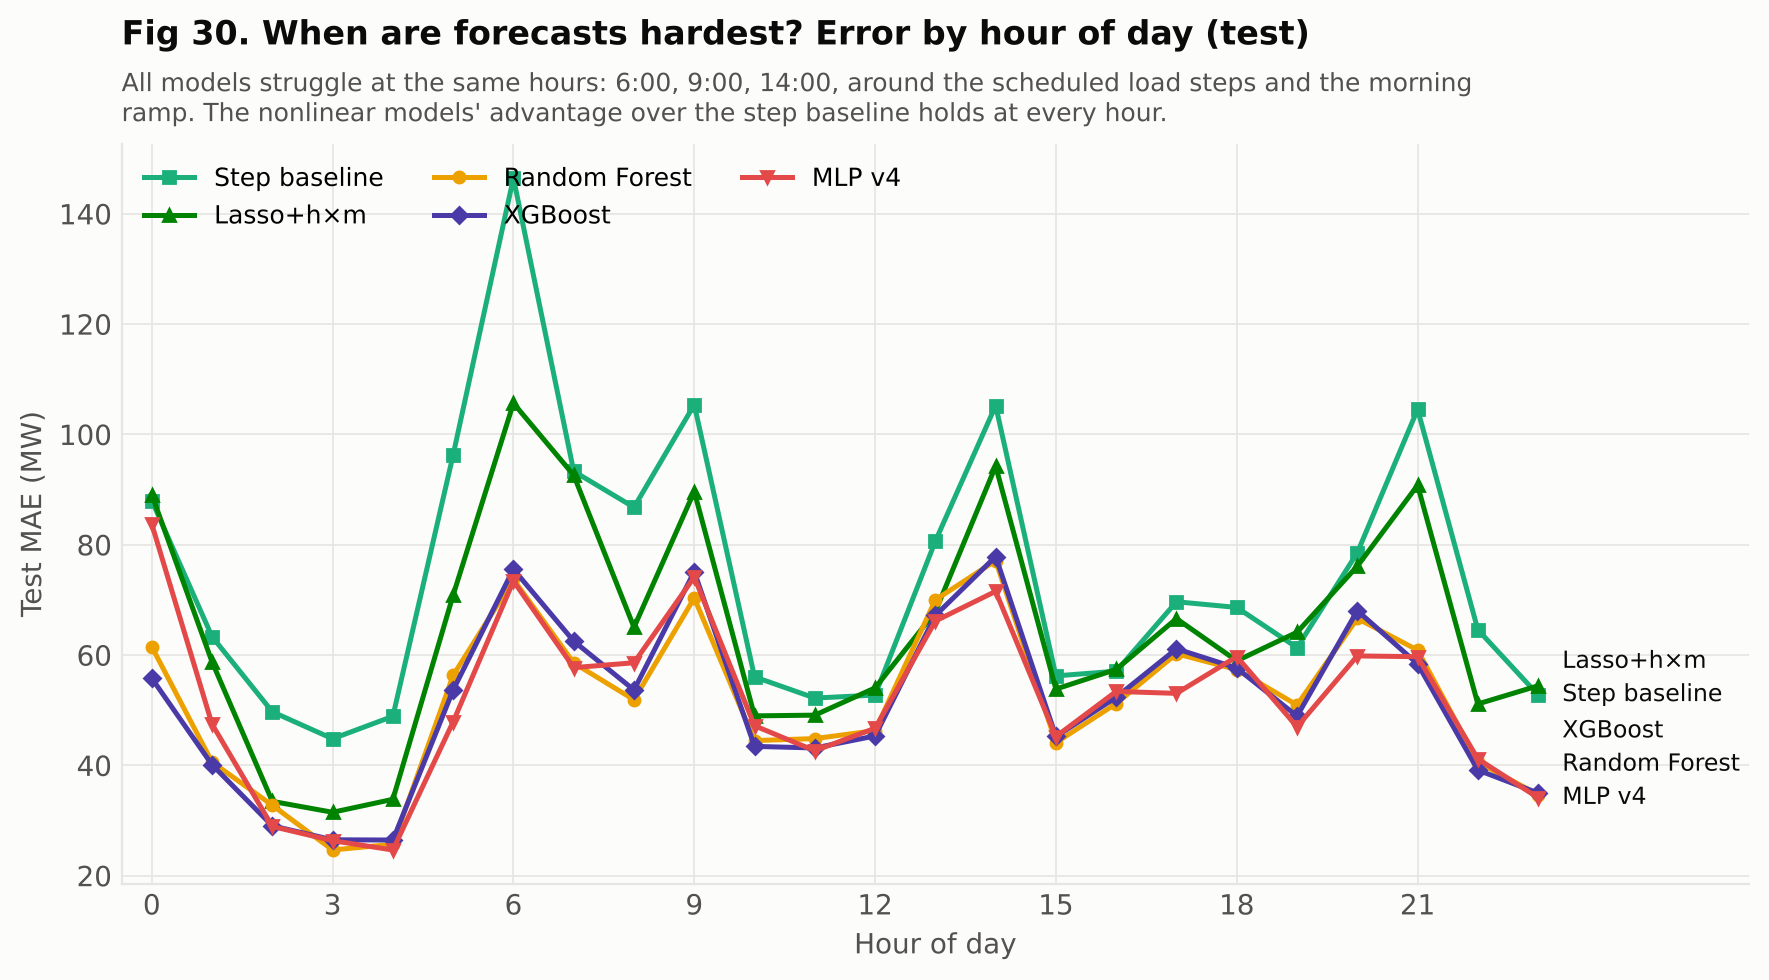

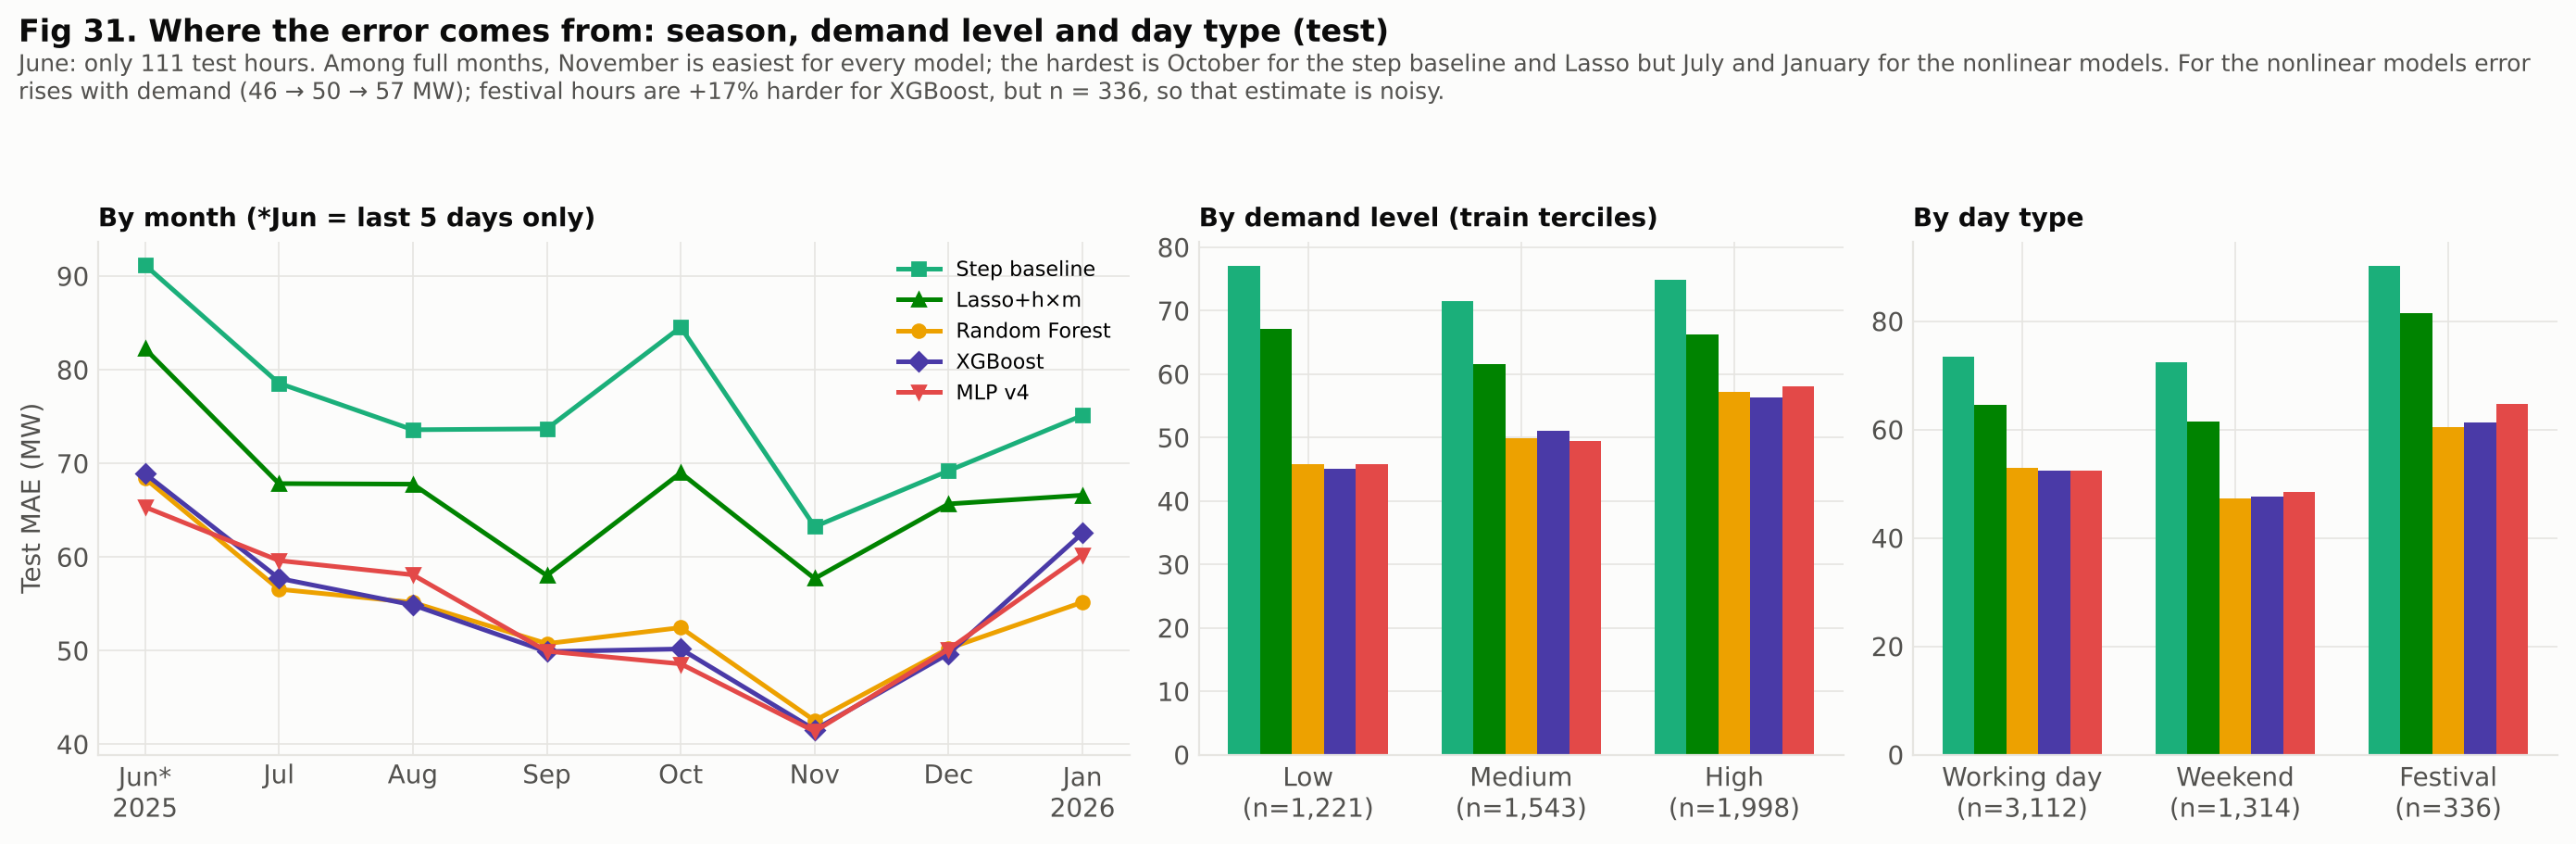

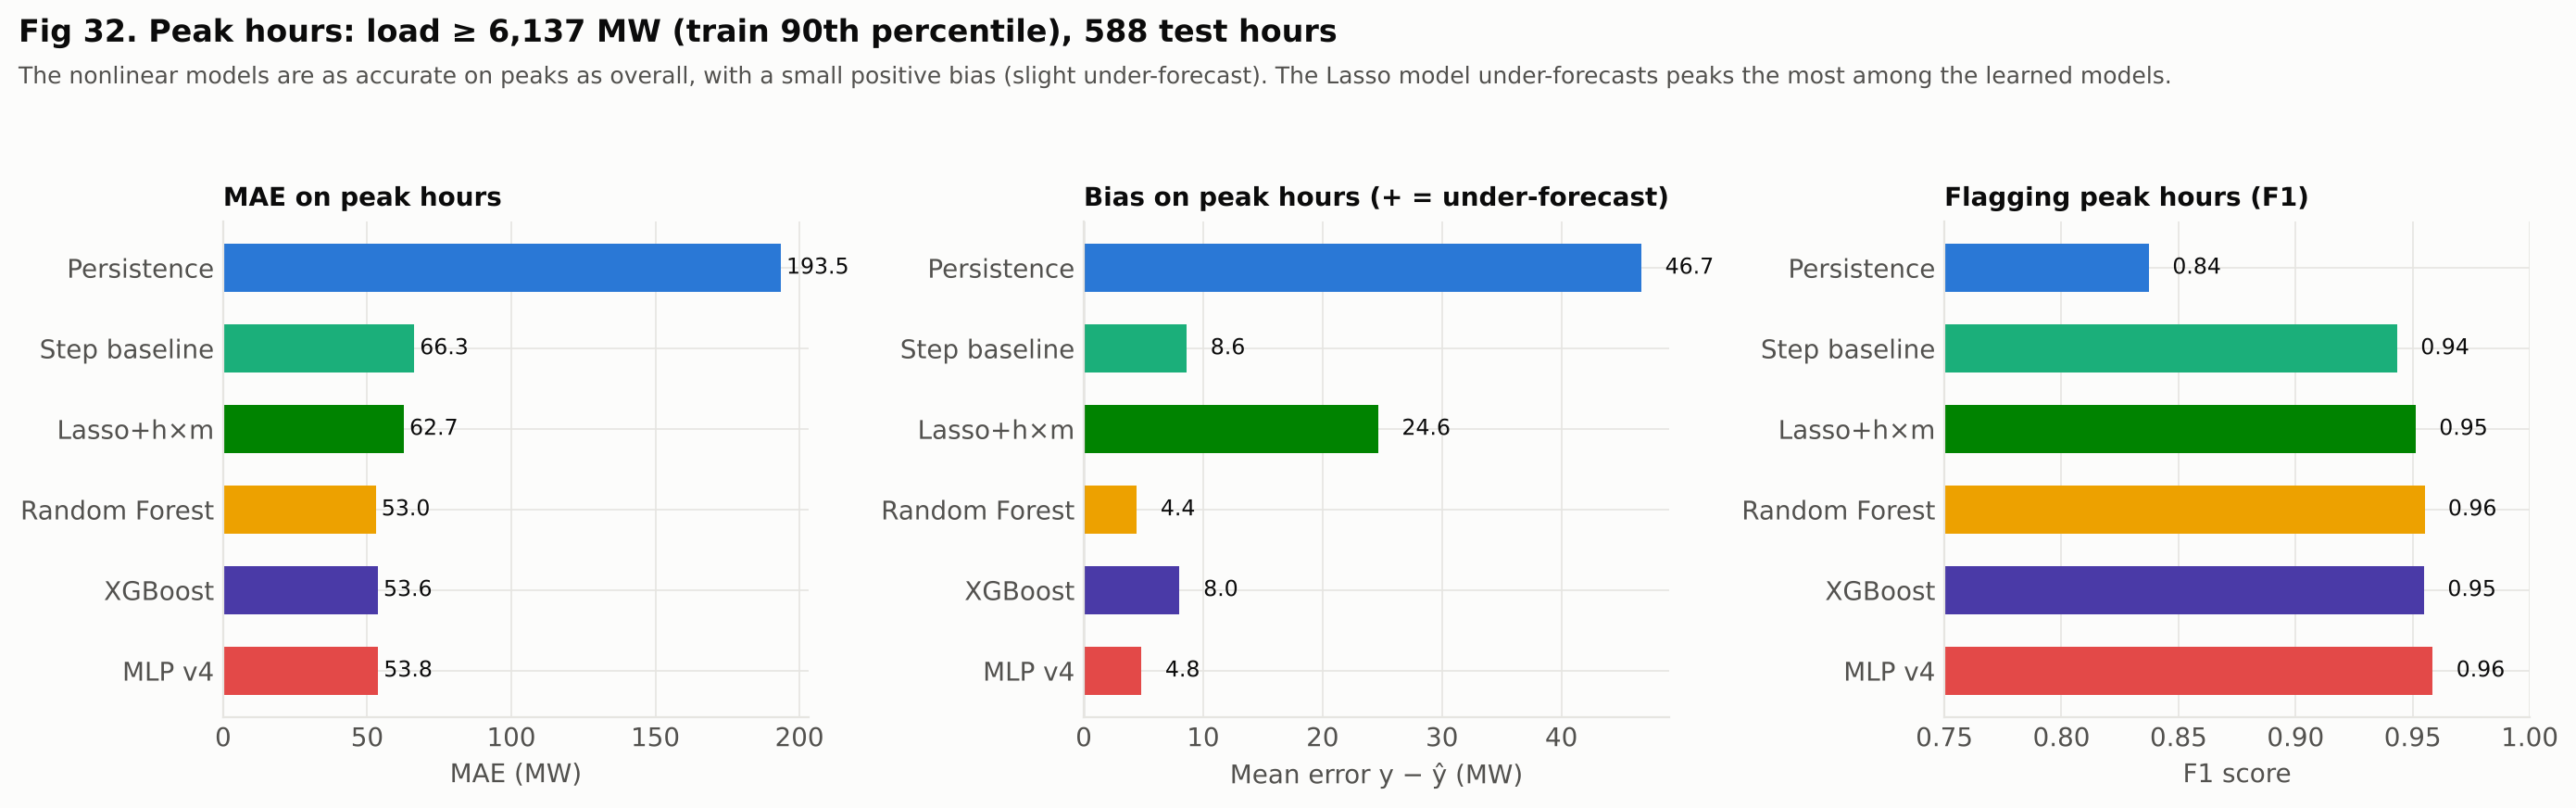

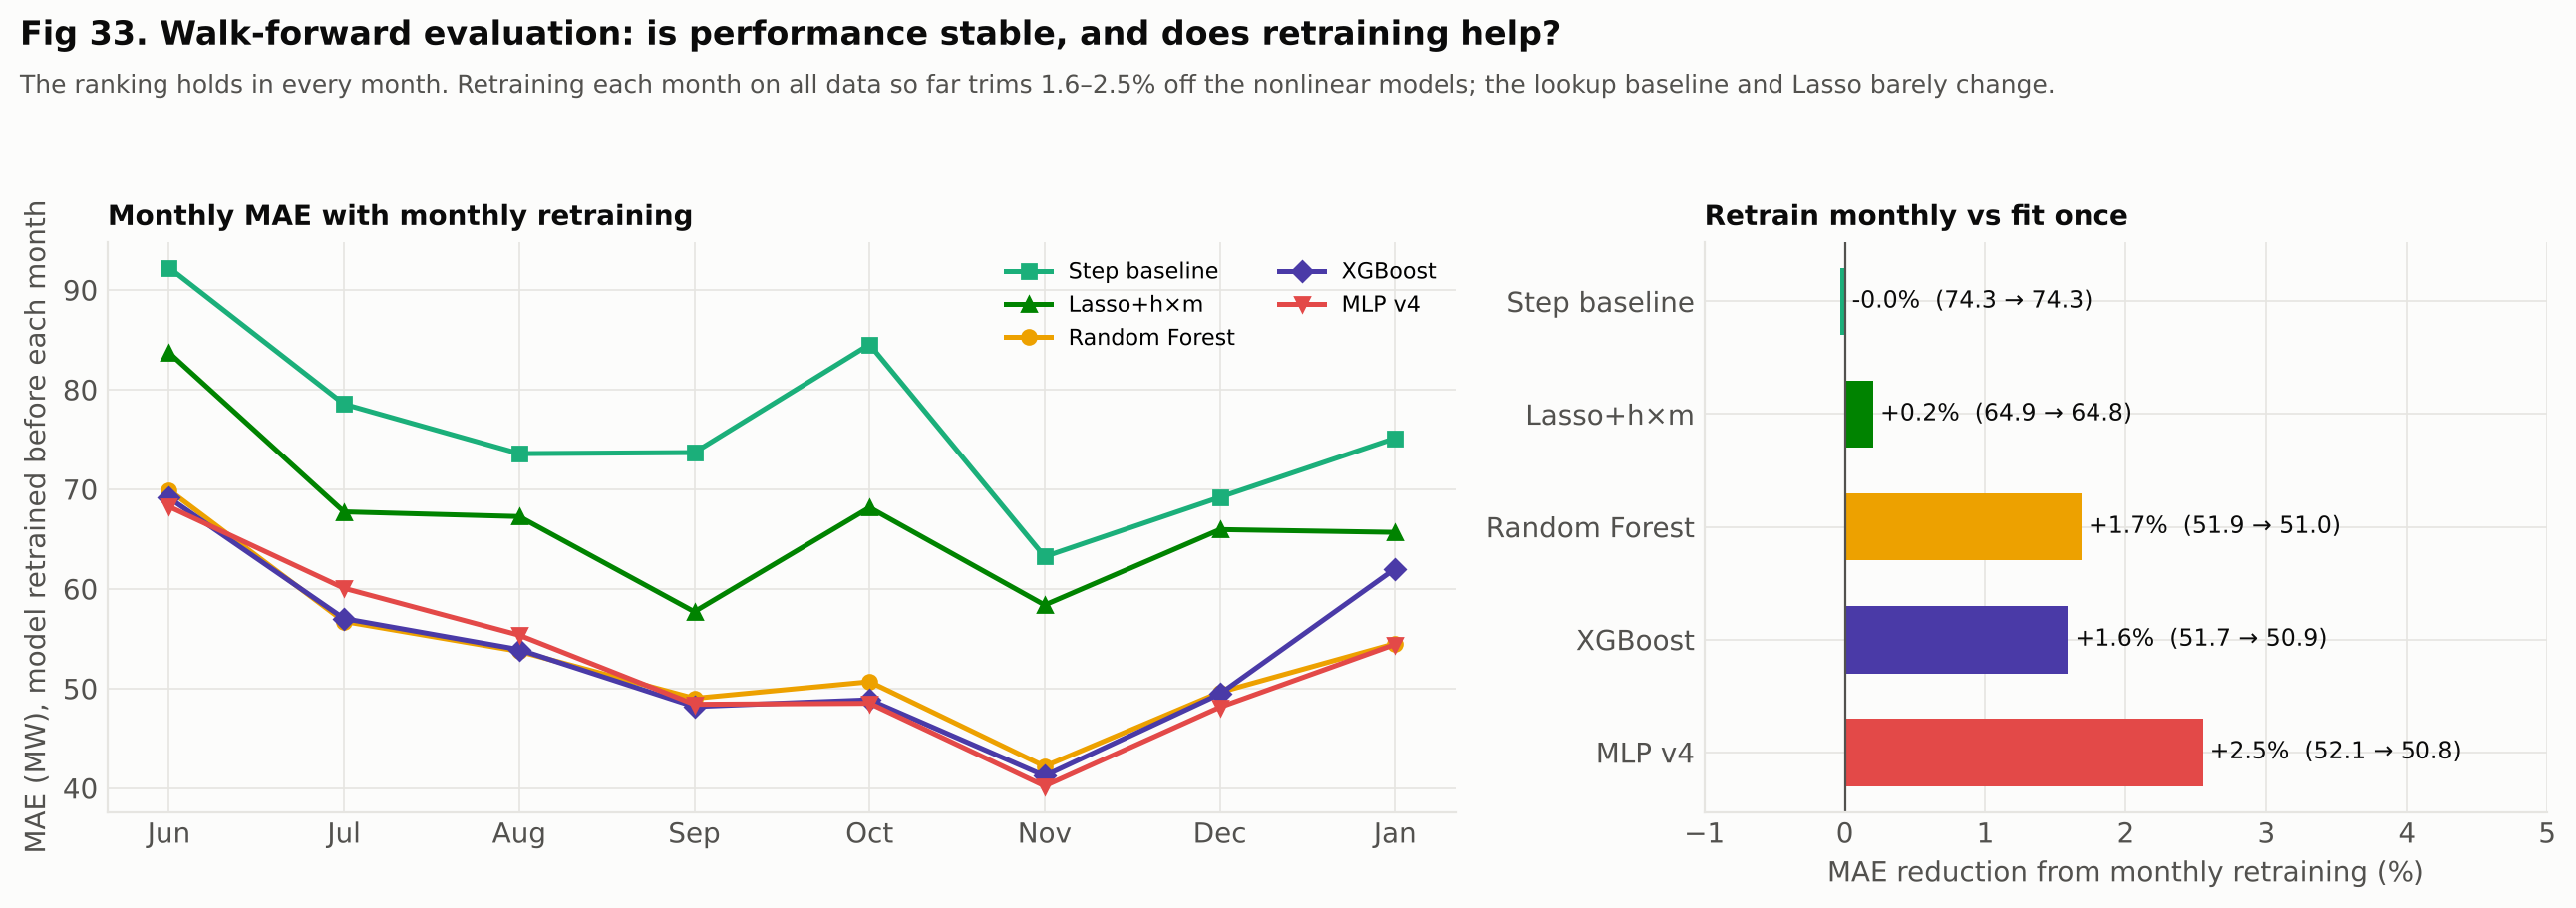

model,Lasso + hour×month,"MLP v4 [64,32] Δ-target",Naive-1 + hourly step,Random Forest,XGBoost
month,,,,,
2025-06,83.7,68.3,92.2,69.9,69.1
2025-07,67.7,60.1,78.5,56.7,57.0
2025-08,67.3,55.4,73.6,53.7,53.9
2025-09,57.7,48.4,73.7,49.0,48.2
2025-10,68.2,48.5,84.5,50.7,48.9
2025-11,58.4,40.2,63.2,42.2,41.2
2025-12,66.0,48.1,69.2,49.6,49.5
2026-01,65.7,54.4,75.1,54.5,62.0


,feature_set,split,n_features,MAE_ensemble,MAE_seed_mean,MAE_seed_std
0,A_load_calendar,val,21,58.84,58.96,0.10
1,A_load_calendar,test,21,51.50,51.61,0.06
2,B_+weather,val,27,59.13,59.25,0.03
3,B_+weather,test,27,51.76,51.88,0.15
4,C_+festival,val,28,59.21,59.32,0.13
5,C_+festival,test,28,51.50,51.62,0.10
6,D_+weather_at_h (what-if),val,33,59.29,59.40,0.05
7,D_+weather_at_h (what-if),test,33,51.84,51.97,0.17


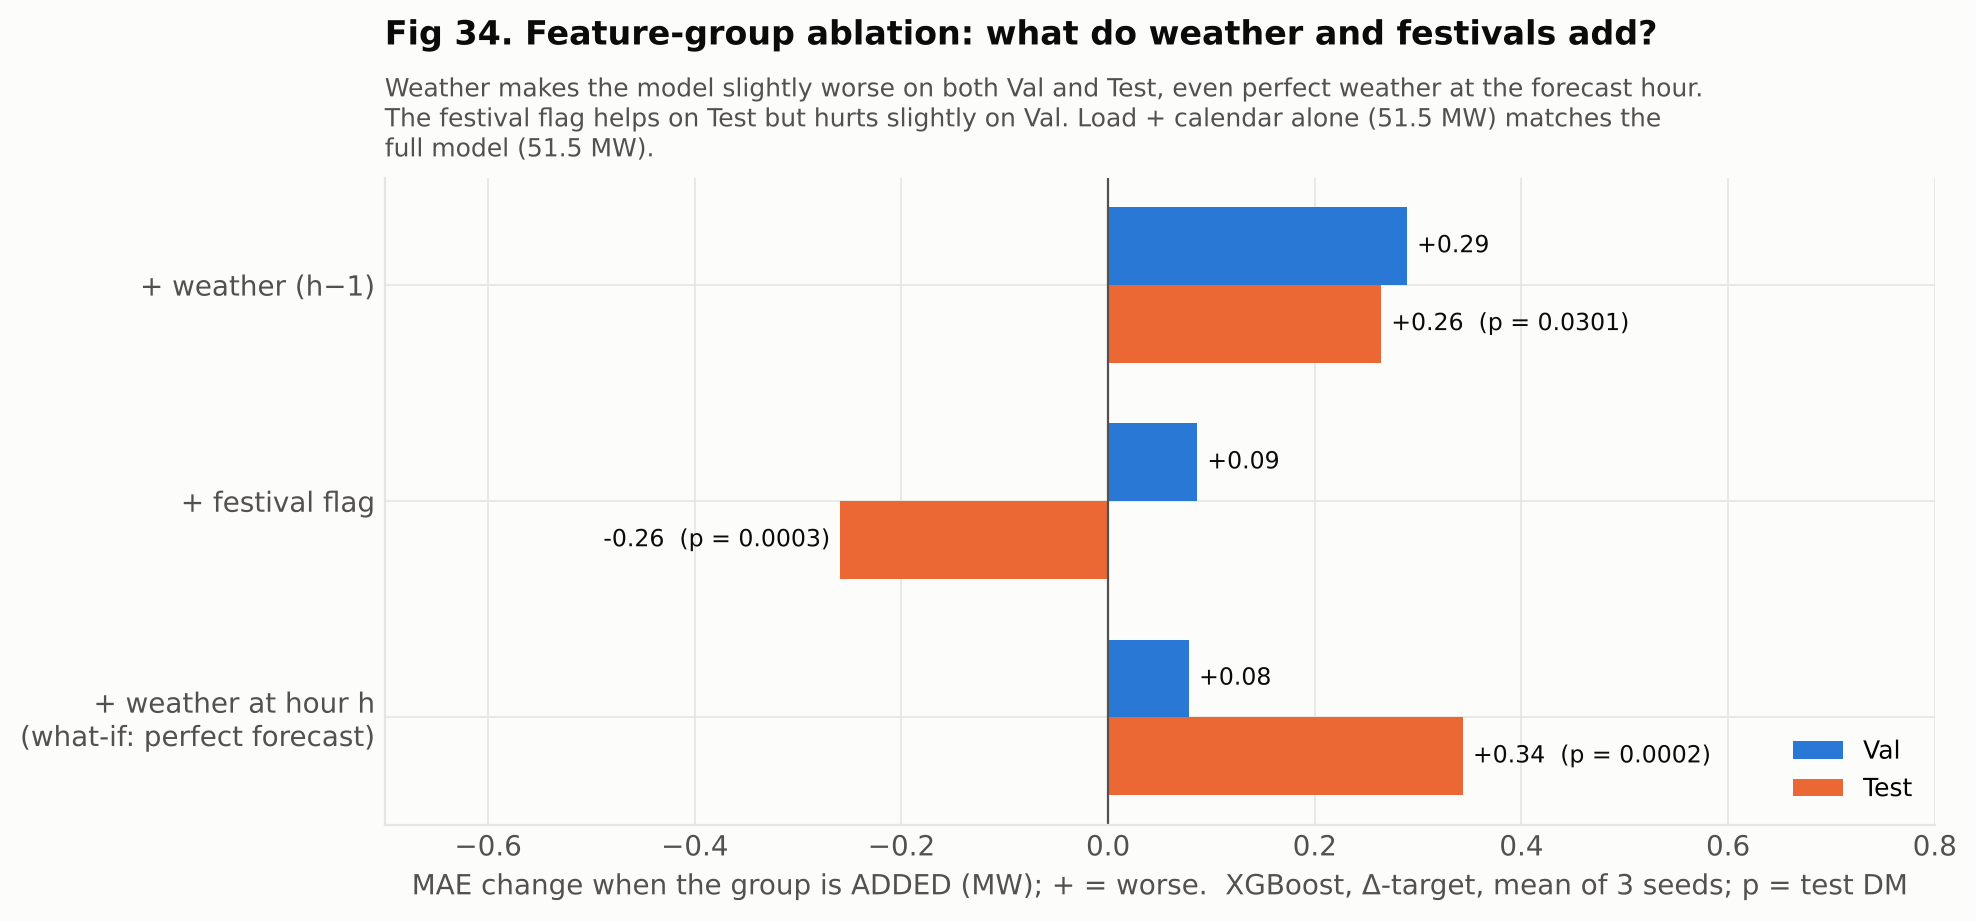

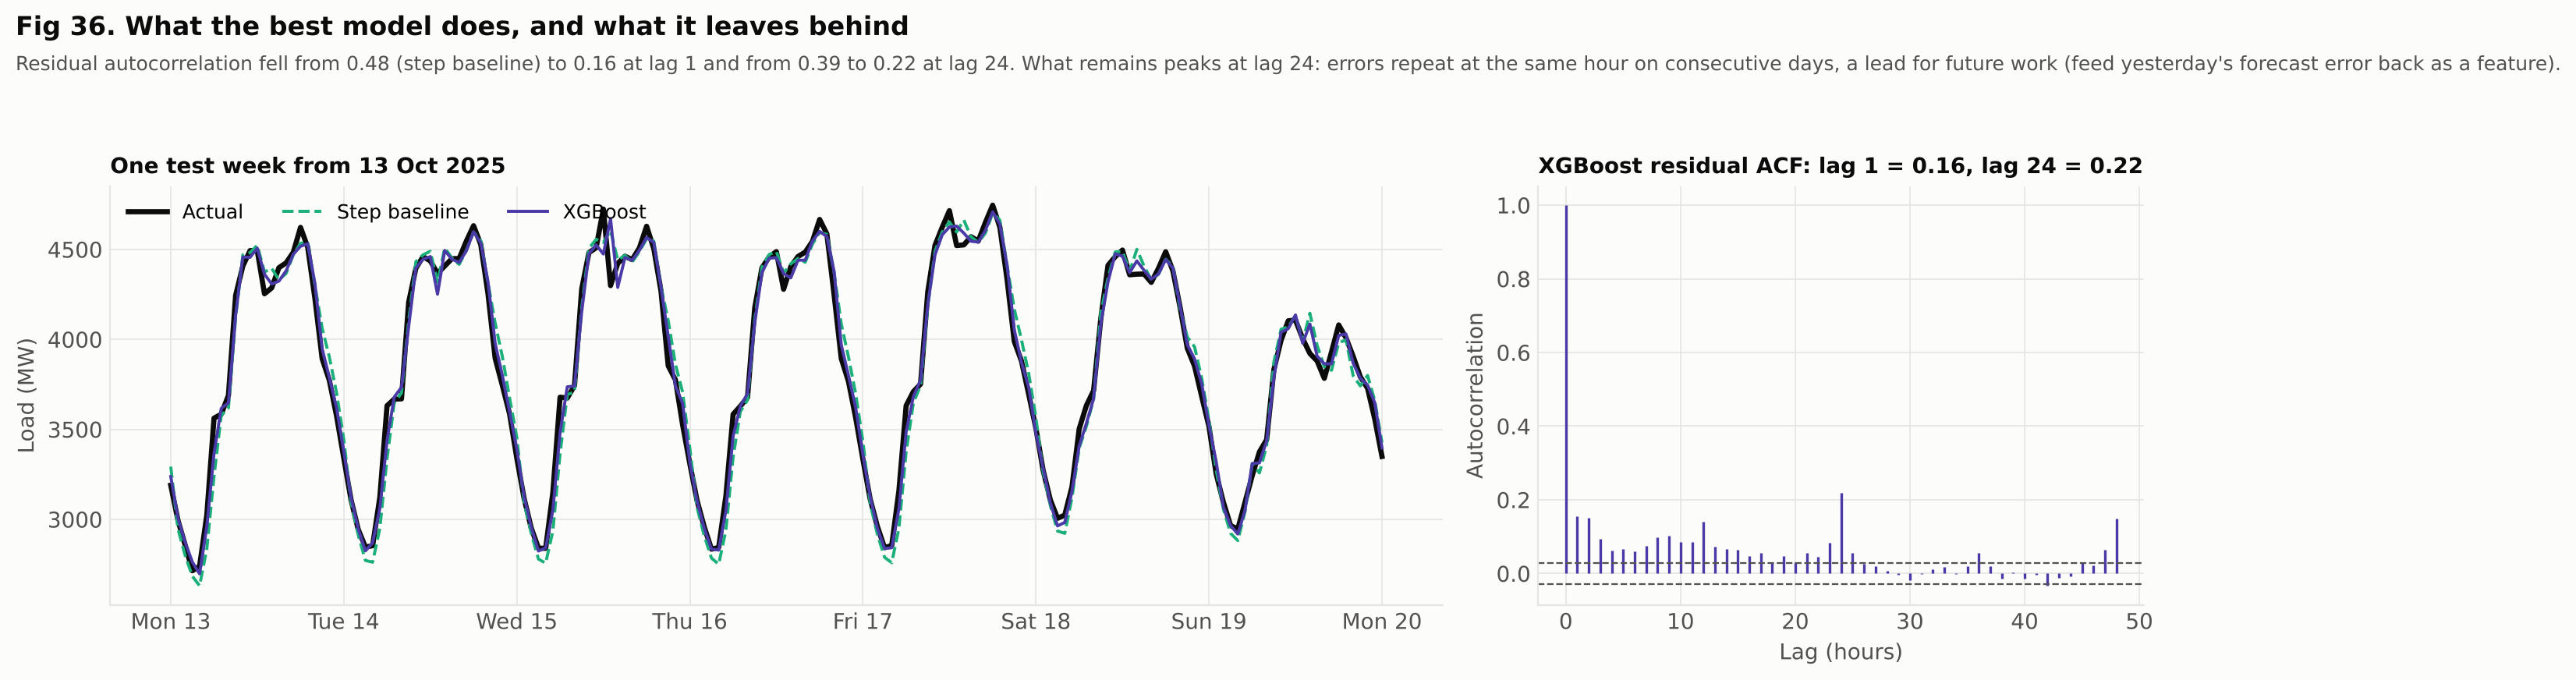


COMBINED ANALYSIS FINISHED


In [9]:
print("\n" + "=" * 88)
print("PHASE 7 — FINAL EVALUATION")
print("=" * 88)

from src import config, compare as cp
import pandas as pd
from IPython.display import Image, display

TD = config.TABLE_DIR
print('Final models:', cp.FINAL)

def safe_show(fig_name, width=900):
    fig = config.FIG_DIR / f"{fig_name}.png"
    if fig.exists():
        display(Image(filename=str(fig), width=width))
    else:
        print(f"[Warning] Figure not found: {fig.name}")

def safe_read_csv(file_path, description):
    try:
        return pd.read_csv(file_path)
    except FileNotFoundError:
        print(f"[Warning] Missing {description} file: {file_path.name}")
        return None

tab = safe_read_csv(TD / 'compare_all.csv', "compare all")
if tab is not None and not tab.empty:
    display(tab[(tab.split == 'test') & (tab.subset == 'all') & tab.final_contender][['model', 'family', 'MAE', 'RMSE', 'MAPE', 'R2', 'Bias', 'skill_vs_step']].sort_values('MAE'))

safe_read_csv(TD / 'compare_ci.csv', "confidence intervals")
safe_show('F28_final_ranking_ci')

safe_read_csv(TD / 'compare_gaps.csv', "MAE gap matrix")
safe_show('F29_mae_gap_matrix', 850)
safe_show('F30_error_by_hour')
safe_show('F31_error_breakdowns', 1100)
safe_show('F32_peak_hours', 1100)
safe_show('F33_walkforward', 1100)

wf = safe_read_csv(TD / 'phase7_walkforward.csv', "walkforward results")
if wf is not None and not wf.empty:
    display(wf.pivot(index='month', columns='model', values='MAE_walkforward').round(1))

abl = safe_read_csv(TD / 'phase7_ablation.csv', "ablation study")
if abl is not None and not abl.empty:
    display(abl.round(2))

safe_show('F34_ablation')
safe_show('F36_week_and_residual_acf', 1100)
print('\n' + '=' * 88)
print('COMBINED ANALYSIS FINISHED')
print('=' * 88)

## Completed
All combined phases have finished.